# SAE-TCAV robustness analysis (legacy comprehensive report)

This notebook preserves the comprehensive analysis that preceded the leakage-safe
temporal-comparison refactor. The pooled and class-stratified semantic-transfer
sections intentionally remain intact; the temporal sections below consume the
normalized results emitted by the new temporal comparison under
`stats/temporal_robustness`.

Run from repository root with Python 3.11 and packages in
`requirements-semantic.txt`. The notebook is read-only with respect to source
artifacts and writes derived tables/plots under `stats/analysis/robustness`.


In [1]:
from __future__ import annotations

from collections import Counter
from hashlib import sha256
import json
import math
import os
from pathlib import Path
import pickle
import tempfile
from typing import Any, Iterable, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

STATS_ROOT = Path("stats")
TEMPORAL_ARTIFACT_ROOT = Path(
    os.environ.get("TEMPORAL_ARTIFACT_DIR", "stats/temporal_robustness")
)
TEMPORAL_RUN_HASH: str | None = os.environ.get("TEMPORAL_RUN_HASH")
RUNNER_DIR: Path | None = None
RUNNER_HASH: str | None = None
CANONICAL_RUN = 0
ACTIVATION_EPSILON = 1e-5
ROBUST_F2_MINIMUM = 0.70
OUTCOME_CLASSES = (0, 1)

SAVE_PLOTS = True
DISPLAY_PLOTS = True
PLOT_FORMAT = "png"
FIGURE_DPI = 160

SUBSET_ORDER = ("all", "non_dead", "precision_recall", "f2", "robust")
SUBSET_LABELS = {
    "all": "All factors",
    "non_dead": "Non-dead",
    "precision_recall": "Precision/recall",
    "f2": "F2",
    "robust": "Robust",
}

RUNNER_REQUIRED = (
    "summary.json",
    "runner_manifest.json",
    "sae_manifest.json",
    "semantic_inputs.npz",
    "activations.npz",
    "prepared.pkl",
    "matched_factors.csv",
    "high_precision_rules.jsonl",
    "functional.json",
    "tabpfn_metrics.json",
)
SEMANTIC_REQUIRED = (
    "manifest.json",
    "semantic_rules.jsonl",
    "pair_results.jsonl",
    "pair_metrics.csv",
    "pair_metrics_by_class.csv",
)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)



## Artifact discovery and strict loading

Absolute paths stored by the producing machine are treated as hints. Relocatable
fallbacks use the runner hash and semantic experiment hash.



In [2]:
def read_json(path: Path) -> Any:
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    with path.open(encoding="utf-8") as handle:
        return [json.loads(line) for line in handle if line.strip()]


def array_fingerprint(array: np.ndarray) -> str:
    value = np.asarray(array)
    digest = sha256()
    digest.update(str(value.dtype).encode())
    digest.update(json.dumps(value.shape).encode())
    if value.dtype.kind in {"O", "U", "S"}:
        digest.update(json.dumps(value.tolist(), separators=(",", ":")).encode())
    else:
        digest.update(np.ascontiguousarray(value).tobytes())
    return digest.hexdigest()


def require_files(root: Path, names: Sequence[str], label: str) -> None:
    missing = [name for name in names if not (root / name).is_file()]
    if missing:
        raise FileNotFoundError(f"{label} missing required artifacts: {missing}")


def semantic_dir_candidates(
    runner_dir: Path, summary: Mapping[str, Any], stats_root: Path
) -> list[Path]:
    experiment_hash = str(summary.get("semantic_experiment_hash", ""))
    raw = summary.get("semantic_artifact_dir")
    candidates: list[Path] = []
    if raw:
        raw_path = Path(str(raw))
        candidates.extend(
            [
                raw_path,
                Path.cwd() / raw_path,
                runner_dir / raw_path,
                stats_root / "semantic" / raw_path.name,
            ]
        )
    if experiment_hash:
        candidates.extend(
            [
                runner_dir / "semantic" / experiment_hash,
                stats_root / "semantic" / experiment_hash,
                runner_dir.parent.parent / "semantic" / experiment_hash,
            ]
        )
    unique: list[Path] = []
    seen: set[str] = set()
    for candidate in candidates:
        key = str(candidate.resolve(strict=False))
        if key not in seen:
            unique.append(candidate)
            seen.add(key)
    return unique


def resolve_semantic_dir(
    runner_dir: Path, summary: Mapping[str, Any], stats_root: Path
) -> Path:
    for candidate in semantic_dir_candidates(runner_dir, summary, stats_root):
        if candidate.is_dir() and all((candidate / name).is_file() for name in SEMANTIC_REQUIRED):
            return candidate
    tried = [str(path) for path in semantic_dir_candidates(runner_dir, summary, stats_root)]
    raise FileNotFoundError(f"No complete semantic artifact directory. Tried: {tried}")


def is_complete_runner(path: Path, stats_root: Path) -> bool:
    try:
        require_files(path, RUNNER_REQUIRED, "runner")
        resolve_semantic_dir(path, read_json(path / "summary.json"), stats_root)
    except (OSError, ValueError, TypeError, KeyError, json.JSONDecodeError):
        return False
    return True


def discover_runner(
    stats_root: Path,
    runner_dir: Path | None = None,
    runner_hash: str | None = None,
) -> tuple[Path, Path, dict[str, Any]]:
    if runner_dir is not None and runner_hash is not None:
        raise ValueError("Set RUNNER_DIR or RUNNER_HASH, not both")
    comparison_root = stats_root / "comparison"
    if runner_dir is not None:
        candidates = [Path(runner_dir)]
    elif runner_hash is not None:
        candidates = [comparison_root / runner_hash]
    else:
        candidates = sorted(
            (
                path
                for path in comparison_root.iterdir()
                if path.is_dir() and path.name != "_cache"
            ),
            key=lambda path: (path / "summary.json").stat().st_mtime
            if (path / "summary.json").is_file()
            else -1,
            reverse=True,
        )
    for candidate in candidates:
        if is_complete_runner(candidate, stats_root):
            summary = read_json(candidate / "summary.json")
            return candidate, resolve_semantic_dir(candidate, summary, stats_root), summary
    raise FileNotFoundError(
        f"No complete runner found among {[str(path) for path in candidates]}"
    )


def prepared_value(prepared: Any, name: str) -> Any:
    if isinstance(prepared, Mapping):
        return prepared[name]
    return getattr(prepared, name)


def load_npz(path: Path, prefix: str) -> dict[int, np.ndarray]:
    with np.load(path, allow_pickle=False) as archive:
        values = {
            int(key.removeprefix(prefix)): np.asarray(archive[key])
            for key in archive.files
            if key.startswith(prefix)
        }
    if not values:
        raise ValueError(f"{path} contains no {prefix}<run_id> arrays")
    return values


def require_columns(frame: pd.DataFrame, columns: Iterable[str], label: str) -> None:
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{label} missing columns: {missing}")


def read_csv_or_empty(path: Path, columns: Sequence[str]) -> pd.DataFrame:
    if path.stat().st_size == 0:
        return pd.DataFrame(columns=list(columns))
    return pd.read_csv(path)


def match_fields(row: Mapping[str, Any]) -> tuple[int, int, int, int]:
    if all(key in row for key in ("sae_i_idx", "sae_j_idx", "original_concept", "best_pair")):
        return (
            int(row["sae_i_idx"]),
            int(row["sae_j_idx"]),
            int(row["original_concept"]),
            int(row["best_pair"]),
        )
    return (
        int(row["run_i"]),
        int(row["run_j"]),
        int(row["factor_i"]),
        int(row["factor_j"]),
    )


def canonical_factor(row: Mapping[str, Any], canonical_run: int) -> int | None:
    run_i, run_j, factor_i, factor_j = match_fields(row)
    if run_i == canonical_run:
        return factor_i
    if run_j == canonical_run:
        return factor_j
    return None


def direct_other_run(row: Mapping[str, Any], canonical_run: int) -> int | None:
    run_i, run_j, _, _ = match_fields(row)
    if run_i == canonical_run:
        return run_j
    if run_j == canonical_run:
        return run_i
    return None


def load_artifacts(
    stats_root: Path,
    runner_dir: Path | None,
    runner_hash: str | None,
    canonical_run: int,
) -> dict[str, Any]:
    runner, semantic, summary = discover_runner(stats_root, runner_dir, runner_hash)
    require_files(runner, RUNNER_REQUIRED, "runner")
    require_files(semantic, SEMANTIC_REQUIRED, "semantic")

    runner_manifest = read_json(runner / "runner_manifest.json")
    sae_manifest = read_json(runner / "sae_manifest.json")
    semantic_manifest = read_json(semantic / "manifest.json")
    if summary["runner_hash"] != runner_manifest["runner_hash"]:
        raise ValueError("summary and runner manifest hashes differ")
    if runner.name != str(summary["runner_hash"]):
        raise ValueError("runner directory name differs from runner hash")
    if str(summary["semantic_experiment_hash"]) != str(semantic_manifest["experiment_hash"]):
        raise ValueError("semantic experiment hashes differ")
    if semantic_manifest["config"]["objective"]["objective"] != "f2":
        raise ValueError("semantic selection objective must equal 'f2'")
    if not bool(semantic_manifest["config"]["class_analysis"]["enabled"]):
        raise ValueError("class analysis must be enabled")

    with np.load(runner / "semantic_inputs.npz", allow_pickle=False) as bundle:
        required_arrays = {"X", "outcome", "patient_ids", "feature_names", "record_keys"}
        missing = required_arrays - set(bundle.files)
        if missing:
            raise ValueError(f"semantic_inputs.npz missing arrays: {sorted(missing)}")
        X = np.asarray(bundle["X"])
        outcome = np.asarray(bundle["outcome"])
        patient_ids = np.asarray(bundle["patient_ids"]).astype(str)
        feature_names = np.asarray(bundle["feature_names"]).astype(str)
        record_keys = np.asarray(bundle["record_keys"]).astype(str)
        activations = {
            int(key.removeprefix("activations_run_")): np.asarray(bundle[key])
            for key in bundle.files
            if key.startswith("activations_run_")
        }
    activation_copy = load_npz(runner / "activations.npz", "run_")
    run_ids = {int(row["run_id"]) for row in sae_manifest}
    if set(activations) != run_ids or set(activation_copy) != run_ids:
        raise ValueError("activation run IDs and SAE manifest differ")
    if canonical_run not in run_ids:
        raise ValueError(f"canonical run {canonical_run} unavailable")

    n_rows = len(X)
    if not (
        len(outcome) == len(patient_ids) == len(record_keys) == n_rows
        == int(runner_manifest["n_test_records"])
        == int(semantic_manifest["n_records"])
    ):
        raise ValueError("row counts differ across bundle and manifests")
    if X.ndim != 2 or X.shape[1] != len(feature_names):
        raise ValueError("X and feature names differ")
    for run_id in sorted(run_ids):
        first, second = activations[run_id], activation_copy[run_id]
        expected_factors = int(next(row["n_factors"] for row in sae_manifest if int(row["run_id"]) == run_id))
        if first.shape != (n_rows, expected_factors):
            raise ValueError(f"run {run_id} activation shape differs from manifest")
        if first.shape != second.shape or not np.array_equal(first, second, equal_nan=True):
            raise ValueError(f"run {run_id} activation archives differ")
        expected_hash = semantic_manifest["activation_fingerprints"][str(run_id)]
        if array_fingerprint(first) != expected_hash:
            raise ValueError(f"run {run_id} activation fingerprint differs")
        if not np.isfinite(first).all():
            raise ValueError(f"run {run_id} activations contain non-finite values")
    for value, key in (
        (np.asarray(X, dtype=float), "data_fingerprint"),
        (outcome, "outcome_fingerprint"),
        (np.asarray(patient_ids, dtype=object), "patient_group_fingerprint"),
    ):
        if array_fingerprint(value) != semantic_manifest[key]:
            raise ValueError(f"{key} differs")

    with (runner / "prepared.pkl").open("rb") as handle:
        prepared = pickle.load(handle)
    years = np.asarray(prepared_value(prepared, "years_test"), dtype=int)
    prepared_outcome = np.asarray(prepared_value(prepared, "y_test"))
    prepared_X = np.asarray(prepared_value(prepared, "X_test"))
    prepared_keys = np.asarray(prepared_value(prepared, "record_keys")).astype(str)
    if not (
        np.array_equal(years.shape, outcome.shape)
        and np.array_equal(prepared_outcome, outcome)
        and np.array_equal(prepared_X, X, equal_nan=True)
        and np.array_equal(prepared_keys, record_keys)
    ):
        raise ValueError("prepared.pkl rows do not align with semantic bundle")
    if array_fingerprint(np.asarray(prepared_value(prepared, "record_keys"))) != runner_manifest["record_fingerprint"]:
        raise ValueError("prepared record fingerprint differs from runner manifest")

    match_columns = (
        "sae_i_idx", "sae_j_idx", "original_concept", "best_pair",
        "cos_sim", "overlap",
    )
    matches = read_csv_or_empty(runner / "matched_factors.csv", match_columns)
    require_columns(
        matches,
        ("sae_i_idx", "sae_j_idx", "original_concept", "best_pair", "cos_sim"),
        "matched_factors.csv",
    )
    high_precision = read_jsonl(runner / "high_precision_rules.jsonl")
    functional = read_json(runner / "functional.json")
    semantic_rules = read_jsonl(semantic / "semantic_rules.jsonl")
    pair_results = read_jsonl(semantic / "pair_results.jsonl")
    pair_required = (
        "pair_id", "run_i", "run_j", "factor_i", "factor_j", "threshold_name",
        "positive_fraction", "i_to_j_precision", "i_to_j_recall", "i_to_j_f2",
        "j_to_i_precision", "j_to_i_recall", "j_to_i_f2",
        "transfer_mean_f2", "transfer_min_f2", "target_cohort_jaccard",
        "selected_cohort_jaccard", "cos_sim",
    )
    class_required = pair_required + (
        "class_value", "class_n_samples", "class_n_positive_i",
        "class_n_positive_j", "class_valid", "class_reasons",
    )
    pair_metrics = read_csv_or_empty(semantic / "pair_metrics.csv", pair_required)
    pair_metrics_class = read_csv_or_empty(
        semantic / "pair_metrics_by_class.csv", class_required
    )
    tabpfn_metrics = pd.DataFrame(read_json(runner / "tabpfn_metrics.json"))
    require_columns(pair_metrics, pair_required, "pair_metrics.csv")
    require_columns(pair_metrics_class, class_required, "pair_metrics_by_class.csv")
    expected_thresholds = {
        row["target"]["name"]
        for row in semantic_rules
        if str(row["run_id"]) == str(canonical_run)
    }
    configured_fractions = semantic_manifest["config"]["activation_targets"]["positive_fractions"]
    configured_names = {
        f"top_{str(int(100 * value)) if float(100 * value).is_integer() else str(100 * value).replace('.', '_')}pct_positive"
        for value in configured_fractions
    }
    if expected_thresholds and expected_thresholds != configured_names:
        raise ValueError("semantic rule threshold names differ from configured activation targets")
    if len(pair_metrics) and set(pair_metrics["threshold_name"].astype(str)) != configured_names:
        raise ValueError("pooled pair threshold names differ from configuration")
    if len(pair_metrics_class) and set(pair_metrics_class["threshold_name"].astype(str)) != configured_names:
        raise ValueError("class pair threshold names differ from configuration")

    if len(matches) != int(runner_manifest["n_selected_matches"]):
        raise ValueError("matched factor count differs from runner manifest")
    if len(matches) != int(summary["n_selected_matches"]):
        raise ValueError("matched factor count differs from summary")
    bounds = {int(item["run_id"]): int(item["n_factors"]) for item in sae_manifest}
    for row in matches.to_dict("records"):
        run_i, run_j, factor_i, factor_j = match_fields(row)
        if not (0 <= factor_i < bounds[run_i] and 0 <= factor_j < bounds[run_j]):
            raise ValueError("matched factor outside SAE bounds")
    for row in semantic_rules:
        run_id, factor_id = int(row["run_id"]), int(row["factor_id"])
        bound = int(next(item["n_factors"] for item in sae_manifest if int(item["run_id"]) == run_id))
        if not 0 <= factor_id < bound:
            raise ValueError("semantic factor outside SAE bounds")
        if row["selection"]["rule_set"]["threshold_name"] != row["target"]["name"]:
            raise ValueError("semantic rule threshold names are inconsistent")
    for row in high_precision:
        run_id, factor_id = int(row["run_id"]), int(row["Factor"])
        if run_id not in bounds or not 0 <= factor_id < bounds[run_id]:
            raise ValueError("high-precision rule factor outside SAE bounds")
        if row.get("Provenance") not in {"high_precision", "forced_fallback"}:
            raise ValueError("unknown high-precision rule provenance")

    pooled_support = pair_metrics.groupby(["pair_id", "threshold_name"], dropna=False).size()
    if not (pooled_support == 1).all():
        raise ValueError("pooled pair metrics must contain one row per pair/threshold")
    expected_pooled_rows = sum(len(pair["thresholds"]) for pair in pair_results)
    expected_class_rows = sum(
        len(threshold.get("class_analysis", []))
        for pair in pair_results
        for threshold in pair["thresholds"]
    )
    if len(pair_metrics) != expected_pooled_rows:
        raise ValueError("pooled CSV row count differs from pair results")
    if len(pair_metrics_class) != expected_class_rows:
        raise ValueError("class CSV row count differs from pair results")
    class_sums = pair_metrics_class.groupby(["pair_id", "threshold_name"])["class_n_samples"].sum()
    pooled_n = {
        (int(pair["pair_id"]), str(threshold["threshold_name"])): int(threshold["transfer"]["n_samples"])
        for pair in pair_results
        for threshold in pair["thresholds"]
    }
    for key, support in class_sums.items():
        if int(support) != pooled_n[(int(key[0]), str(key[1]))]:
            raise ValueError(f"class support does not sum to pooled support for {key}")
    manifest_support = {
        str(key): int(value)
        for key, value in semantic_manifest["class_analysis"]["class_support"].items()
    }
    for (_, threshold), group in pair_metrics_class.groupby(["pair_id", "threshold_name"]):
        observed = {
            str(row.class_value): int(row.class_n_samples)
            for row in group.itertuples()
        }
        if observed != manifest_support:
            raise ValueError(f"class support differs from manifest at threshold {threshold}")

    return {
        "runner_dir": runner,
        "semantic_dir": semantic,
        "summary": summary,
        "runner_manifest": runner_manifest,
        "sae_manifest": sae_manifest,
        "semantic_manifest": semantic_manifest,
        "X": X,
        "outcome": outcome,
        "patient_ids": patient_ids,
        "feature_names": feature_names,
        "record_keys": record_keys,
        "years": years,
        "activations": activations,
        "matches": matches,
        "high_precision": high_precision,
        "functional": functional,
        "semantic_rules": semantic_rules,
        "pair_results": pair_results,
        "pair_metrics": pair_metrics,
        "pair_metrics_class": pair_metrics_class,
        "tabpfn_metrics": tabpfn_metrics,
        "threshold_names": tuple(sorted(configured_names)),
        "run_ids": tuple(sorted(run_ids)),
    }



## Subset gates and validation checks



In [3]:
def precision_recall_factors(
    rows: Sequence[Mapping[str, Any]], canonical_run: int
) -> set[int]:
    return {
        int(row["Factor"])
        for row in rows
        if int(row["run_id"]) == canonical_run
        and row.get("Provenance") == "high_precision"
    }


def f2_factors(
    rows: Sequence[Mapping[str, Any]], canonical_run: int
) -> set[int]:
    return {
        int(row["factor_id"])
        for row in rows
        if int(row["run_id"]) == canonical_run
        and bool(row.get("valid"))
        and bool(row.get("selection", {}).get("feasible"))
    }


def robust_gate(
    canonical_factor_id: int,
    direct_rows: pd.DataFrame,
    semantic_rule_lookup: Mapping[tuple[int, int, str], Mapping[str, Any]],
    other_runs: set[int],
    threshold_names: set[str],
    minimum_f2: float,
) -> tuple[bool, str]:
    rows = direct_rows[direct_rows["canonical_factor"] == canonical_factor_id]
    matched_runs = set(rows["other_run"].astype(int))
    missing_runs = sorted(other_runs - matched_runs)
    if missing_runs:
        return False, f"missing_run_match:{','.join(map(str, missing_runs))}"
    for other_run in sorted(other_runs):
        run_rows = rows[rows["other_run"].astype(int) == other_run]
        observed = set(run_rows["threshold_name"].astype(str))
        missing_thresholds = sorted(threshold_names - observed)
        if missing_thresholds:
            return False, f"missing_threshold:{other_run}:{','.join(missing_thresholds)}"
        if run_rows.groupby("threshold_name").size().max() != 1:
            return False, f"duplicate_threshold:{other_run}"
        for threshold in sorted(threshold_names):
            metric = run_rows[run_rows["threshold_name"].astype(str) == threshold].iloc[0]
            canonical_model = semantic_rule_lookup.get(
                (CANONICAL_RUN, canonical_factor_id, threshold)
            )
            other_factor = int(metric["other_factor"])
            other_model = semantic_rule_lookup.get((other_run, other_factor, threshold))
            if canonical_model is None or other_model is None:
                return False, f"missing_model:{other_run}:{threshold}"
            if not (canonical_model.get("valid") and other_model.get("valid")):
                return False, f"invalid_model:{other_run}:{threshold}"
            value = pd.to_numeric(pd.Series([metric["transfer_min_f2"]]), errors="coerce").iloc[0]
            if not np.isfinite(value) or float(value) < minimum_f2:
                return False, f"transfer_below_gate:{other_run}:{threshold}"
    return True, ""


def direct_semantic_rows(frame: pd.DataFrame, canonical_run: int) -> pd.DataFrame:
    rows = []
    for row in frame.to_dict("records"):
        factor = canonical_factor(row, canonical_run)
        other = direct_other_run(row, canonical_run)
        if factor is None or other is None:
            continue
        run_i, run_j, factor_i, factor_j = match_fields(row)
        other_factor = factor_j if run_i == canonical_run else factor_i
        rows.append(
            {
                **row,
                "canonical_factor": factor,
                "other_run": other,
                "other_factor": other_factor,
            }
        )
    return pd.DataFrame(
        rows,
        columns=list(frame.columns)
        + ["canonical_factor", "other_run", "other_factor"],
    )


def run_unit_checks() -> None:
    assert precision_recall_factors(
        [
            {"run_id": 0, "Factor": 1, "Provenance": "high_precision"},
            {"run_id": 0, "Factor": 2, "Provenance": "forced_fallback"},
        ],
        0,
    ) == {1}
    assert f2_factors(
        [
            {"run_id": 0, "factor_id": 1, "valid": True, "selection": {"feasible": False}},
            {"run_id": 0, "factor_id": 1, "valid": True, "selection": {"feasible": True}},
            {"run_id": 0, "factor_id": 2, "valid": False, "selection": {"feasible": True}},
        ],
        0,
    ) == {1}

    thresholds = {"top_10pct_positive"}
    direct = pd.DataFrame(
        [
            {
                "canonical_factor": 0,
                "other_run": 1,
                "other_factor": 4,
                "threshold_name": "top_10pct_positive",
                "transfer_min_f2": ROBUST_F2_MINIMUM,
            }
        ]
    )
    lookup = {
        (0, 0, "top_10pct_positive"): {"valid": True, "selection": {"feasible": True}},
        (1, 4, "top_10pct_positive"): {"valid": True, "selection": {"feasible": True}},
    }
    assert robust_gate(0, direct, lookup, {1}, thresholds, ROBUST_F2_MINIMUM)[0]
    assert not robust_gate(0, direct.iloc[0:0], lookup, {1}, thresholds, ROBUST_F2_MINIMUM)[0]
    invalid = dict(lookup)
    invalid[(1, 4, "top_10pct_positive")] = {"valid": False, "selection": {"feasible": True}}
    assert not robust_gate(0, direct, invalid, {1}, thresholds, ROBUST_F2_MINIMUM)[0]
    assert not robust_gate(0, direct, lookup, {1}, {"missing"}, ROBUST_F2_MINIMUM)[0]

    with tempfile.TemporaryDirectory() as temporary:
        stats = Path(temporary) / "stats"
        semantic = stats / "semantic" / "experiment"
        semantic.mkdir(parents=True)
        for name in SEMANTIC_REQUIRED:
            (semantic / name).touch()
        for index, name in enumerate(("old", "new")):
            runner = stats / "comparison" / name
            runner.mkdir(parents=True)
            for required in RUNNER_REQUIRED:
                (runner / required).touch()
            (runner / "summary.json").write_text(
                json.dumps(
                    {
                        "semantic_experiment_hash": "experiment",
                        "semantic_artifact_dir": str(semantic),
                    }
                ),
                encoding="utf-8",
            )
            os.utime(runner / "summary.json", (100 + index, 100 + index))
        selected, _, _ = discover_runner(stats)
        assert selected.name == "new"


run_unit_checks()
print("Pure validation checks passed.")



Pure validation checks passed.


## Load selected completed run



In [4]:
artifacts = load_artifacts(
    STATS_ROOT,
    RUNNER_DIR,
    RUNNER_HASH,
    CANONICAL_RUN,
)
RUNNER_HASH_RESOLVED = str(artifacts["summary"]["runner_hash"])
OUTPUT_DIR = STATS_ROOT / "analysis" / "robustness" / RUNNER_HASH_RESOLVED
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Runner: {artifacts['runner_dir']}")
print(f"Semantic artifacts: {artifacts['semantic_dir']}")
print(f"Output: {OUTPUT_DIR}")



Runner: stats/comparison/a89788e527b7c1ed3003
Semantic artifacts: /home/joaomarcostomaz/SAE-TCAV-extension/SAE-TCAV/stats/comparison/a89788e527b7c1ed3003/semantic/e93e72e6125c0cf8f357
Output: stats/analysis/robustness/a89788e527b7c1ed3003


## Canonical registry and overlapping factor membership



,subset,n_selected,fraction_of_all,n_globally_dead,n_matched_all_runs,n_valid_all_thresholds
0,all,288,1.000000,0,4,0
1,non_dead,288,1.000000,0,4,0
2,precision_recall,6,0.020833,0,0,0
3,f2,1,0.003472,0,0,0
4,robust,0,0.000000,0,0,0


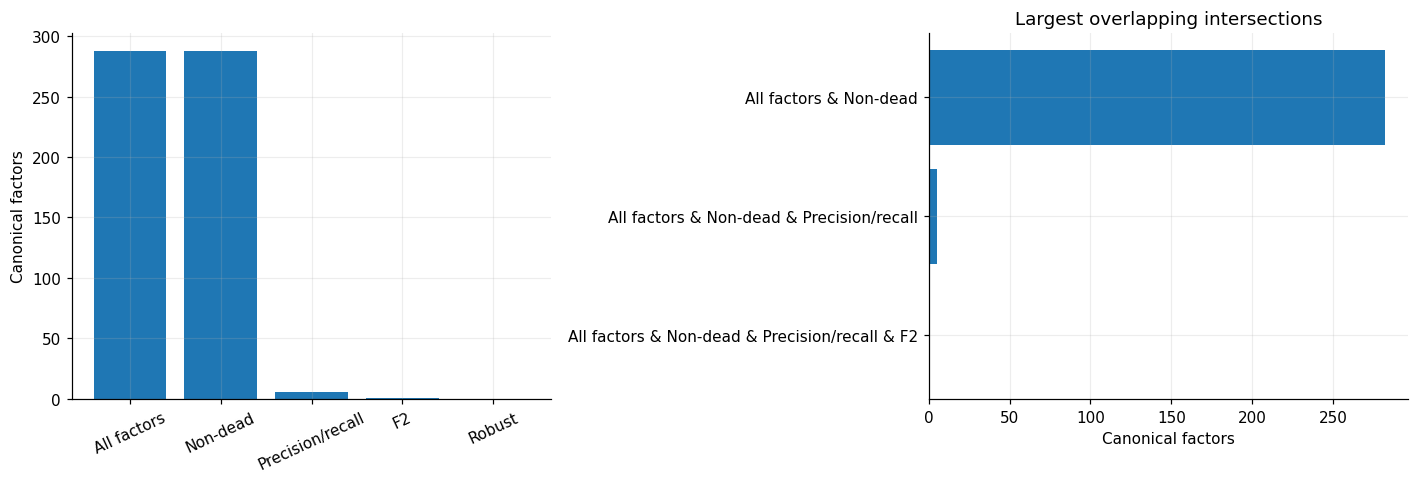

In [5]:
canonical_activations = artifacts["activations"][CANONICAL_RUN]
n_factors = canonical_activations.shape[1]
all_factors = set(range(n_factors))
precision_factors = precision_recall_factors(
    artifacts["high_precision"], CANONICAL_RUN
)
f2_selected = f2_factors(artifacts["semantic_rules"], CANONICAL_RUN)

semantic_lookup = {
    (int(row["run_id"]), int(row["factor_id"]), str(row["target"]["name"])): row
    for row in artifacts["semantic_rules"]
}
direct_metrics = direct_semantic_rows(artifacts["pair_metrics"], CANONICAL_RUN)
other_runs = set(artifacts["run_ids"]) - {CANONICAL_RUN}
robust_reasons: dict[int, str] = {}
robust_factors: set[int] = set()
for factor_id in sorted(all_factors):
    valid, reason = robust_gate(
        factor_id,
        direct_metrics,
        semantic_lookup,
        other_runs,
        set(artifacts["threshold_names"]),
        ROBUST_F2_MINIMUM,
    )
    robust_reasons[factor_id] = reason
    if valid:
        robust_factors.add(factor_id)

fixed_subsets = {
    "all": all_factors,
    "precision_recall": precision_factors,
    "f2": f2_selected,
    "robust": robust_factors,
}
matched_runs_by_factor = (
    direct_metrics.groupby("canonical_factor")["other_run"].nunique().to_dict()
    if not direct_metrics.empty
    else {}
)
valid_thresholds_by_factor = Counter()
for factor_id in all_factors:
    valid_thresholds_by_factor[factor_id] = sum(
        bool(semantic_lookup.get((CANONICAL_RUN, factor_id, threshold), {}).get("valid"))
        and bool(
            semantic_lookup.get((CANONICAL_RUN, factor_id, threshold), {})
            .get("selection", {})
            .get("feasible")
        )
        for threshold in artifacts["threshold_names"]
    )

membership_rows = []
for factor_id in sorted(all_factors):
    flags = {
        "all": True,
        "non_dead": bool(np.any(canonical_activations[:, factor_id] > ACTIVATION_EPSILON)),
        "precision_recall": factor_id in precision_factors,
        "f2": factor_id in f2_selected,
        "robust": factor_id in robust_factors,
    }
    for subset in SUBSET_ORDER:
        membership_rows.append(
            {
                "canonical_run": CANONICAL_RUN,
                "factor_id": factor_id,
                "subset": subset,
                "selected": flags[subset],
                "globally_non_dead": flags["non_dead"],
                "matched_run_count": int(matched_runs_by_factor.get(factor_id, 0)),
                "matched_run_coverage": (
                    matched_runs_by_factor.get(factor_id, 0) / len(other_runs)
                    if other_runs
                    else np.nan
                ),
                "valid_threshold_count": int(valid_thresholds_by_factor[factor_id]),
                "required_threshold_count": len(artifacts["threshold_names"]),
                "robust_invalid_reason": robust_reasons[factor_id],
                "robust_is_posthoc": subset == "robust",
            }
        )
factor_membership = pd.DataFrame(membership_rows)
factor_membership.to_csv(OUTPUT_DIR / "factor_membership.csv", index=False)

inventory_rows = []
for subset in SUBSET_ORDER:
    selected = set(
        factor_membership.loc[
            (factor_membership["subset"] == subset) & factor_membership["selected"],
            "factor_id",
        ]
    )
    inventory_rows.append(
        {
            "subset": subset,
            "n_selected": len(selected),
            "fraction_of_all": len(selected) / n_factors if n_factors else np.nan,
            "n_globally_dead": sum(
                not np.any(canonical_activations[:, factor] > ACTIVATION_EPSILON)
                for factor in selected
            ),
            "n_matched_all_runs": sum(
                matched_runs_by_factor.get(factor, 0) == len(other_runs)
                for factor in selected
            ),
            "n_valid_all_thresholds": sum(
                valid_thresholds_by_factor[factor] == len(artifacts["threshold_names"])
                for factor in selected
            ),
        }
    )
subset_inventory = pd.DataFrame(inventory_rows)

flag_wide = factor_membership.pivot(
    index="factor_id", columns="subset", values="selected"
).fillna(False)
intersection_counts = (
    flag_wide.astype(bool)
    .value_counts()
    .rename("n_factors")
    .reset_index()
)
intersection_counts["intersection"] = intersection_counts.apply(
    lambda row: " & ".join(
        SUBSET_LABELS[name] for name in SUBSET_ORDER if bool(row[name])
    )
    or "None",
    axis=1,
)
intersection_counts.to_csv(OUTPUT_DIR / "subset_intersections.csv", index=False)
subset_inventory.to_csv(OUTPUT_DIR / "subset_inventory.csv", index=False)
display(subset_inventory)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(
    [SUBSET_LABELS[name] for name in subset_inventory["subset"]],
    subset_inventory["n_selected"],
)
axes[0].set_ylabel("Canonical factors")
axes[0].tick_params(axis="x", rotation=25)
top_intersections = intersection_counts.nlargest(12, "n_factors")
axes[1].barh(top_intersections["intersection"], top_intersections["n_factors"])
axes[1].invert_yaxis()
axes[1].set_xlabel("Canonical factors")
axes[1].set_title("Largest overlapping intersections")
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(OUTPUT_DIR / f"subset_inventory.{PLOT_FORMAT}", dpi=FIGURE_DPI, bbox_inches="tight")
if DISPLAY_PLOTS:
    plt.show()
else:
    plt.close(fig)



## Temporal robustness from the new comparison

The historical activation-level temporal calculation was replaced here with
the frozen, reference-specific outputs in `stats/temporal_robustness`. The
new estimands are shown directly: re-contextualized model F1, primary-rule
F2, activation prevalence ratio, geometric factor recurrence, and Jaccard.
Cohort views and rule sources stay separate; they are not relabeled as the
old pooled/class subsets.


In [6]:
from artifact_storage import read_artifact


def resolve_temporal_parent(root: Path, run_hash: str | None = None) -> Path:
    if run_hash:
        candidate = root / run_hash / "parent_manifest.json"
        if candidate.is_file():
            return candidate
        raise FileNotFoundError(f"Temporal run {run_hash!r} not found under {root}")
    direct = root / "parent_manifest.json"
    candidates = [direct] if direct.is_file() else []
    candidates.extend(root.glob("*/parent_manifest.json"))
    complete = []
    for candidate in candidates:
        try:
            manifest = read_json(candidate)
        except (OSError, ValueError, TypeError, json.JSONDecodeError):
            continue
        if manifest.get("complete") is True and manifest.get("aggregate_artifacts"):
            complete.append(candidate)
    if not complete:
        raise FileNotFoundError(f"No complete temporal parent manifest under {root}")
    return max(complete, key=lambda candidate: candidate.stat().st_mtime)


def load_temporal_table(parent_path: Path, name: str) -> pd.DataFrame:
    parent = read_json(parent_path)
    descriptor = parent.get("aggregate_artifacts", {}).get(name)
    if descriptor is None:
        return pd.DataFrame()
    value = read_artifact(parent_path.parent, descriptor)
    if not isinstance(value, list):
        raise ValueError(f"Temporal artifact {name!r} is not a row table")
    return pd.DataFrame(value)


TEMPORAL_PARENT_PATH = resolve_temporal_parent(
    TEMPORAL_ARTIFACT_ROOT, TEMPORAL_RUN_HASH
)
TEMPORAL_PARENT = read_json(TEMPORAL_PARENT_PATH)
if TEMPORAL_PARENT.get("schema_version") != "2.0":
    raise ValueError("This adapted report requires temporal artifact schema 2.0")
if TEMPORAL_PARENT.get("complete") is not True:
    raise ValueError("Temporal parent manifest is not complete")

performance = load_temporal_table(TEMPORAL_PARENT_PATH, "performance")
factor_year_metrics = load_temporal_table(
    TEMPORAL_PARENT_PATH, "factor_year_metrics"
)
distance_summaries = load_temporal_table(
    TEMPORAL_PARENT_PATH, "distance_summaries"
)
uncertainty = load_temporal_table(TEMPORAL_PARENT_PATH, "uncertainty")
lead_lag = load_temporal_table(TEMPORAL_PARENT_PATH, "lead_lag")
change_points = load_temporal_table(TEMPORAL_PARENT_PATH, "change_points")

require_columns(
    performance,
    ("cohort_view", "reference_year", "test_year", "temporal_distance", "macro_f1", "death_f1"),
    "temporal performance",
)
require_columns(
    factor_year_metrics,
    (
        "cohort_view", "rule_source", "target_role", "matching_view",
        "cosine_threshold", "temporal_distance", "f2", "prevalence_ratio",
        "geometric_factor_recurrence", "factor_family_uid",
    ),
    "temporal factor-year metrics",
)

for frame, columns in (
    (performance, ("temporal_distance", "macro_f1", "death_f1")),
    (factor_year_metrics, ("temporal_distance", "f2", "prevalence_ratio", "geometric_factor_recurrence")),
):
    for column in columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

TEMPORAL_HEADLINE_COSINE = float(
    TEMPORAL_PARENT.get("config", {}).get("matching", {}).get(
        "headline_cosine_threshold", 0.60
    )
)
TEMPORAL_HEADLINE_VIEW = "cosine_qualified"

headline_factors = factor_year_metrics[
    (factor_year_metrics["matching_view"] == TEMPORAL_HEADLINE_VIEW)
    & factor_year_metrics["cosine_threshold"].eq(TEMPORAL_HEADLINE_COSINE)
    & factor_year_metrics["target_role"].eq("primary")
].copy()

factor_by_distance = (
    headline_factors.groupby(
        ["cohort_view", "rule_source", "temporal_distance"],
        dropna=False,
        as_index=False,
    )
    .agg(
        f2=("f2", "mean"),
        prevalence_ratio=("prevalence_ratio", "mean"),
        geometric_factor_recurrence=("geometric_factor_recurrence", "mean"),
        jaccard=("jaccard", "mean"),
        n_factor_rows=("factor_family_uid", "size"),
        n_factor_families=("factor_family_uid", "nunique"),
    )
)

performance_by_distance = (
    performance.groupby(["cohort_view", "temporal_distance"], as_index=False)
    .agg(
        macro_f1=("macro_f1", "mean"),
        death_f1=("death_f1", "mean"),
        n_performance_rows=("macro_f1", "count"),
    )
)

temporal_metrics = factor_by_distance.copy()
temporal_by_distance = factor_by_distance.copy()
temporal_metrics.to_csv(OUTPUT_DIR / "temporal_metrics.csv", index=False)
temporal_by_distance.to_csv(OUTPUT_DIR / "temporal_by_distance.csv", index=False)
performance_by_distance.to_csv(OUTPUT_DIR / "temporal_performance_by_distance.csv", index=False)

print(f"Temporal source: {TEMPORAL_PARENT_PATH}")
print(f"Headline temporal factor rows: {len(headline_factors):,}")
display(performance_by_distance.head(15))
display(factor_by_distance.head(15))
display(pd.DataFrame({
    "table": ["performance", "factor_year_metrics", "distance_summaries", "uncertainty", "lead_lag", "change_points"],
    "rows": [len(performance), len(factor_year_metrics), len(distance_summaries), len(uncertainty), len(lead_lag), len(change_points)],
}))


Temporal source: stats/temporal_robustness/6284a624c93d5b632390/parent_manifest.json
Headline temporal factor rows: 14,819


,cohort_view,temporal_distance,macro_f1,death_f1,n_performance_rows
0,all_comer,0,0.497870,0.036328,27
1,all_comer,1,0.479880,0.001121,24
2,all_comer,2,0.479544,0.000805,21
3,all_comer,3,0.479735,0.000512,18
4,all_comer,4,0.479709,0.000000,15
5,all_comer,5,0.481363,0.000000,12
6,all_comer,6,0.482529,0.000000,9
7,all_comer,7,0.483380,0.000000,6
8,all_comer,8,0.489282,0.000000,3
9,new_entrant,1,0.479050,0.004233,21


,cohort_view,rule_source,temporal_distance,f2,prevalence_ratio,geometric_factor_recurrence,jaccard,n_factor_rows,n_factor_families
0,all_comer,high_precision,0,0.572423,1.000000,1.0,0.512718,443,215
1,all_comer,high_precision,1,0.295421,1.251832,1.0,0.213254,389,188
2,all_comer,high_precision,2,0.269056,1.096920,1.0,0.194307,342,165
3,all_comer,high_precision,3,0.265619,1.023077,1.0,0.191393,297,142
4,all_comer,high_precision,4,0.259334,1.016455,1.0,0.192168,266,124
5,all_comer,high_precision,5,0.231689,1.171540,1.0,0.167743,213,97
6,all_comer,high_precision,6,0.239768,1.286109,1.0,0.178752,158,72
7,all_comer,high_precision,7,0.226075,1.243124,1.0,0.160602,106,48
8,all_comer,high_precision,8,0.166907,1.017182,1.0,0.089985,39,20
9,all_comer,semantic,0,0.716167,1.000000,1.0,0.554767,138,81


,table,rows
0,performance,675
1,factor_year_metrics,668393
2,distance_summaries,661
3,uncertainty,4840
4,lead_lag,2
5,change_points,18


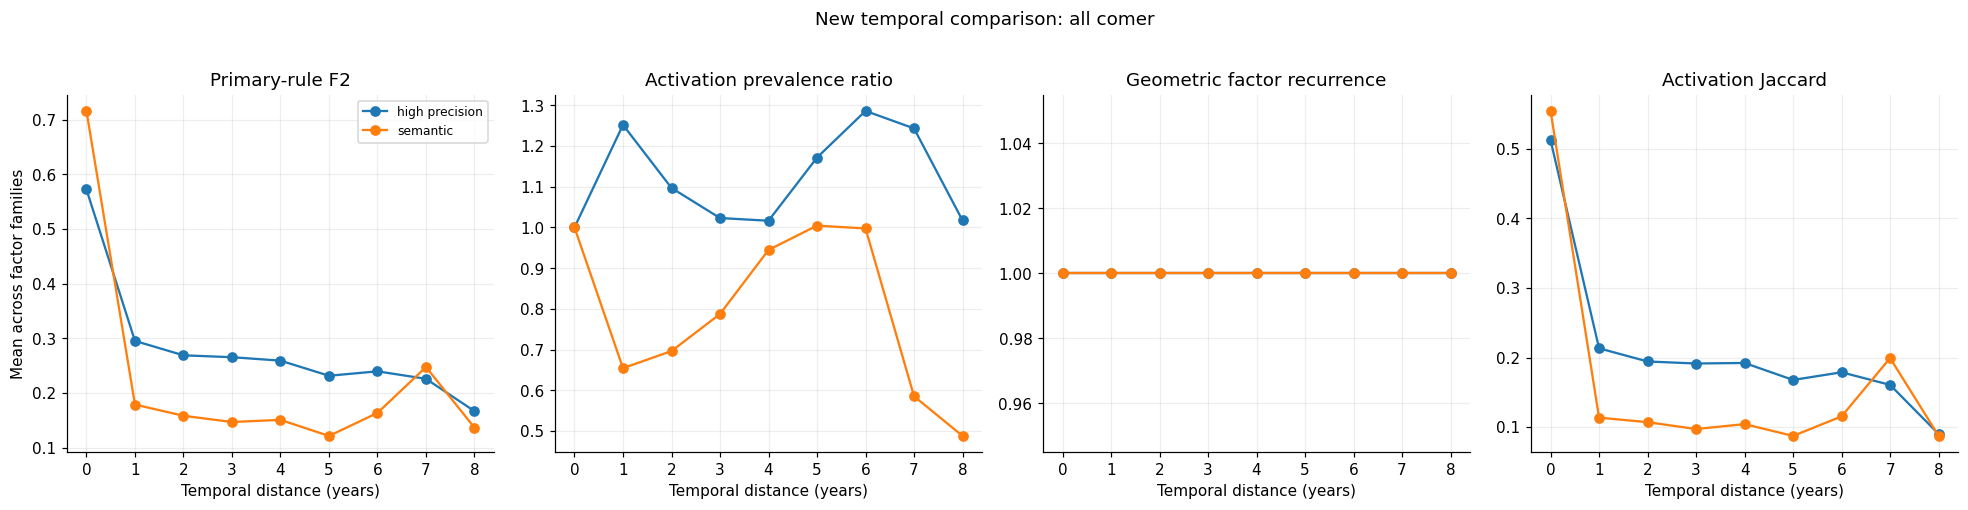

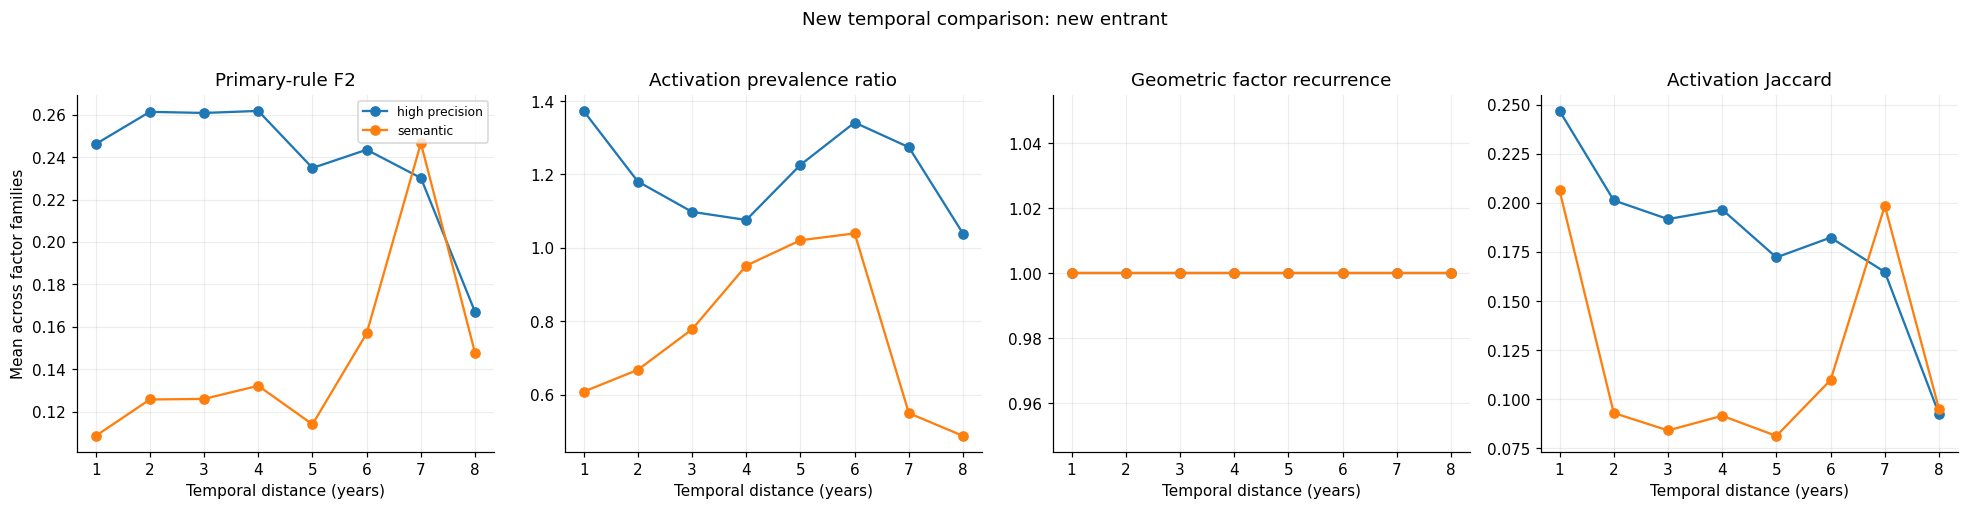

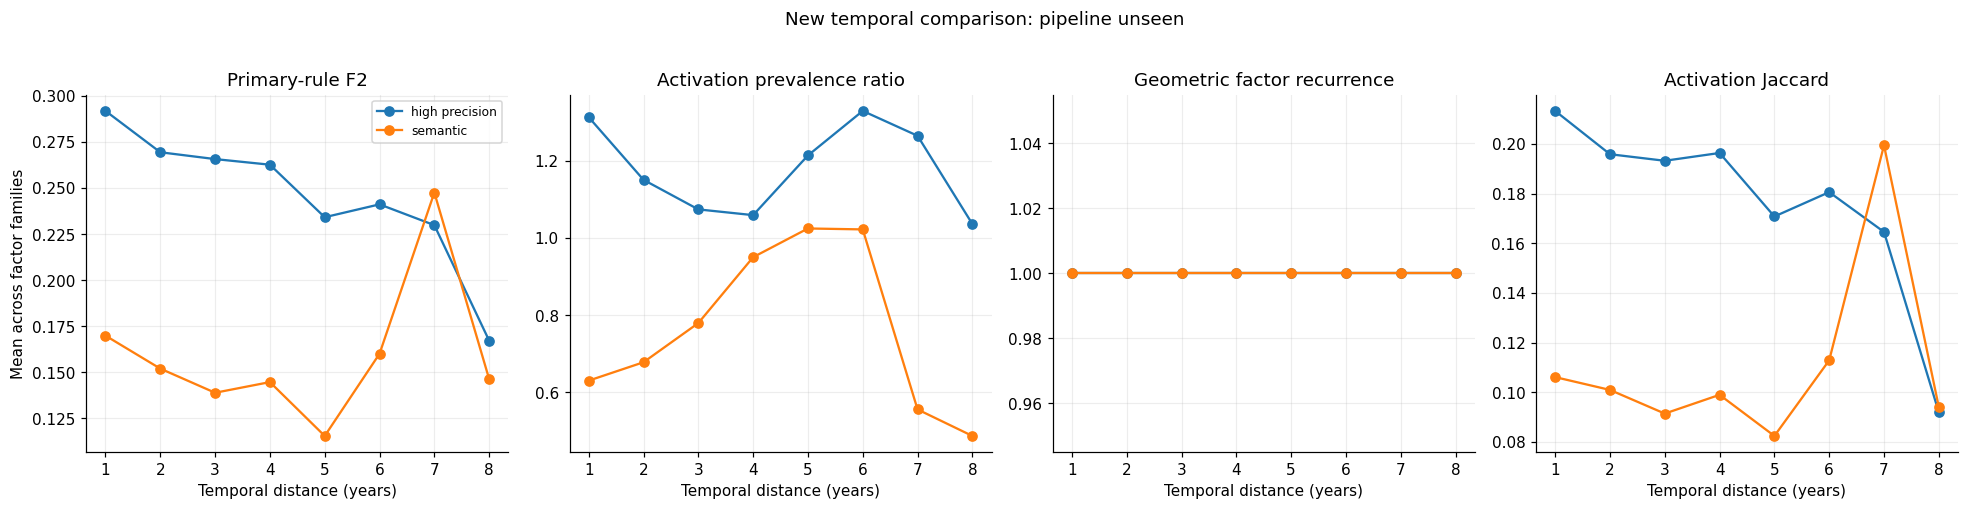

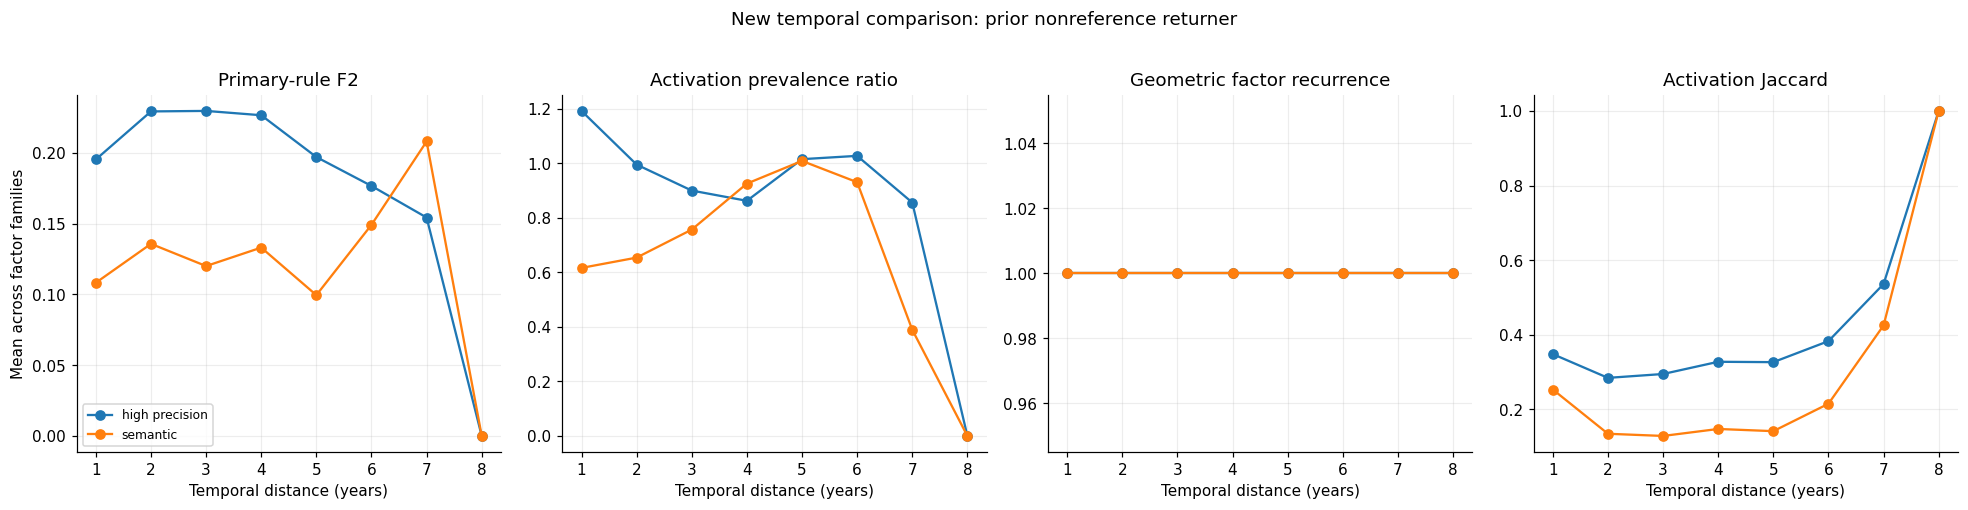

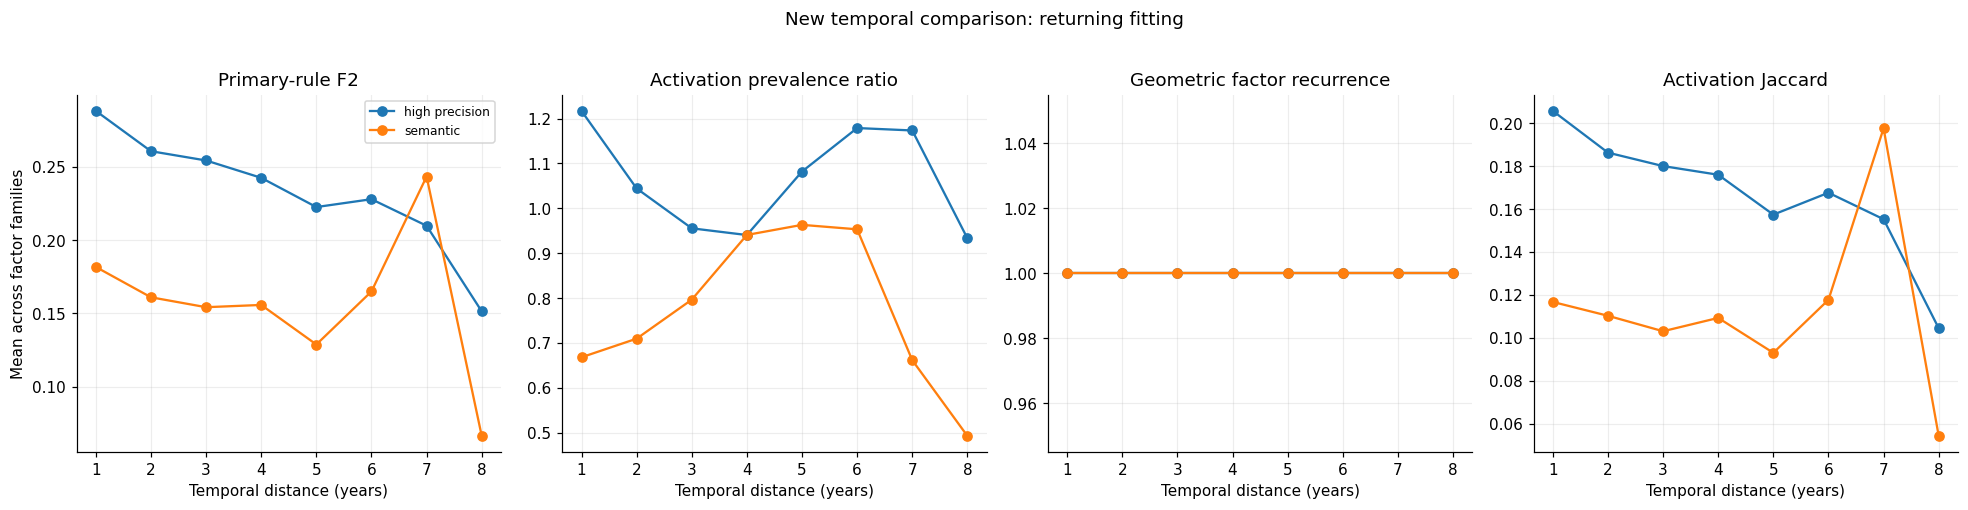

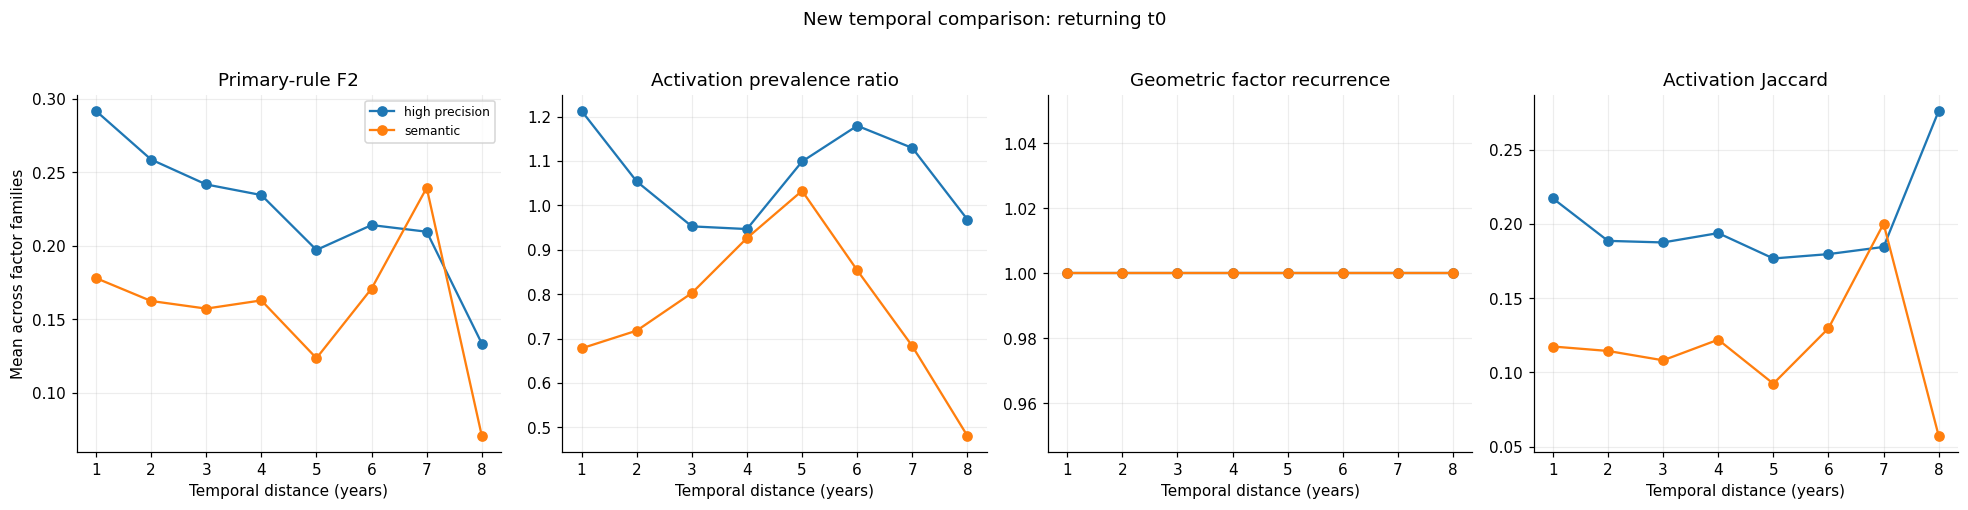

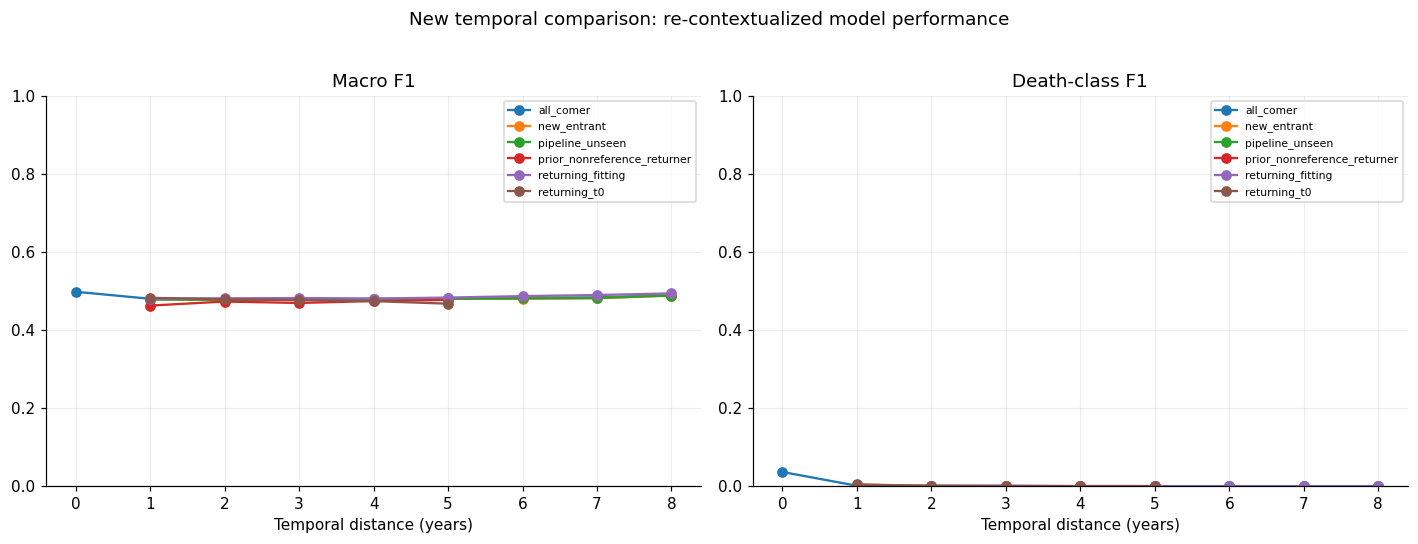

In [7]:
TEMPORAL_PLOT_METRICS = (
    ("f2", "Primary-rule F2"),
    ("prevalence_ratio", "Activation prevalence ratio"),
    ("geometric_factor_recurrence", "Geometric factor recurrence"),
    ("jaccard", "Activation Jaccard"),
)


def finish_figure(fig: plt.Figure, filename: str) -> None:
    fig.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(
            OUTPUT_DIR / f"{filename}.{PLOT_FORMAT}",
            dpi=FIGURE_DPI,
            bbox_inches="tight",
        )
    if DISPLAY_PLOTS:
        plt.show()
    else:
        plt.close(fig)


def plot_temporal_cohort(cohort_view: str) -> None:
    selected = factor_by_distance[
        factor_by_distance["cohort_view"] == cohort_view
    ]
    if selected.empty:
        return
    fig, axes = plt.subplots(1, len(TEMPORAL_PLOT_METRICS), figsize=(18, 4.5))
    for axis, (metric, label) in zip(axes, TEMPORAL_PLOT_METRICS):
        for rule_source, rows in selected.groupby("rule_source"):
            rows = rows.sort_values("temporal_distance")
            axis.plot(
                rows["temporal_distance"],
                rows[metric],
                marker="o",
                label=rule_source.replace("_", " "),
            )
        axis.set_title(label)
        axis.set_xlabel("Temporal distance (years)")
    axes[0].set_ylabel("Mean across factor families")
    axes[0].legend(fontsize=8)
    fig.suptitle(
        f"New temporal comparison: {cohort_view.replace('_', ' ')}",
        y=1.02,
    )
    finish_figure(fig, f"temporal_new_{cohort_view}")


for cohort_name in sorted(factor_by_distance["cohort_view"].dropna().unique()):
    plot_temporal_cohort(str(cohort_name))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for cohort_name, rows in performance_by_distance.groupby("cohort_view"):
    rows = rows.sort_values("temporal_distance")
    axes[0].plot(rows["temporal_distance"], rows["macro_f1"], marker="o", label=cohort_name)
    axes[1].plot(rows["temporal_distance"], rows["death_f1"], marker="o", label=cohort_name)
axes[0].set_title("Macro F1")
axes[1].set_title("Death-class F1")
for axis in axes:
    axis.set_xlabel("Temporal distance (years)")
    axis.set_ylim(0.0, 1.0)
    axis.legend(fontsize=7)
fig.suptitle("New temporal comparison: re-contextualized model performance", y=1.02)
finish_figure(fig, "temporal_new_model_performance")


## Drift and model performance from the new temporal comparison

These plots use the parent-level temporal artifacts rather than the legacy
`concept_drift_full.pkl` fallback.


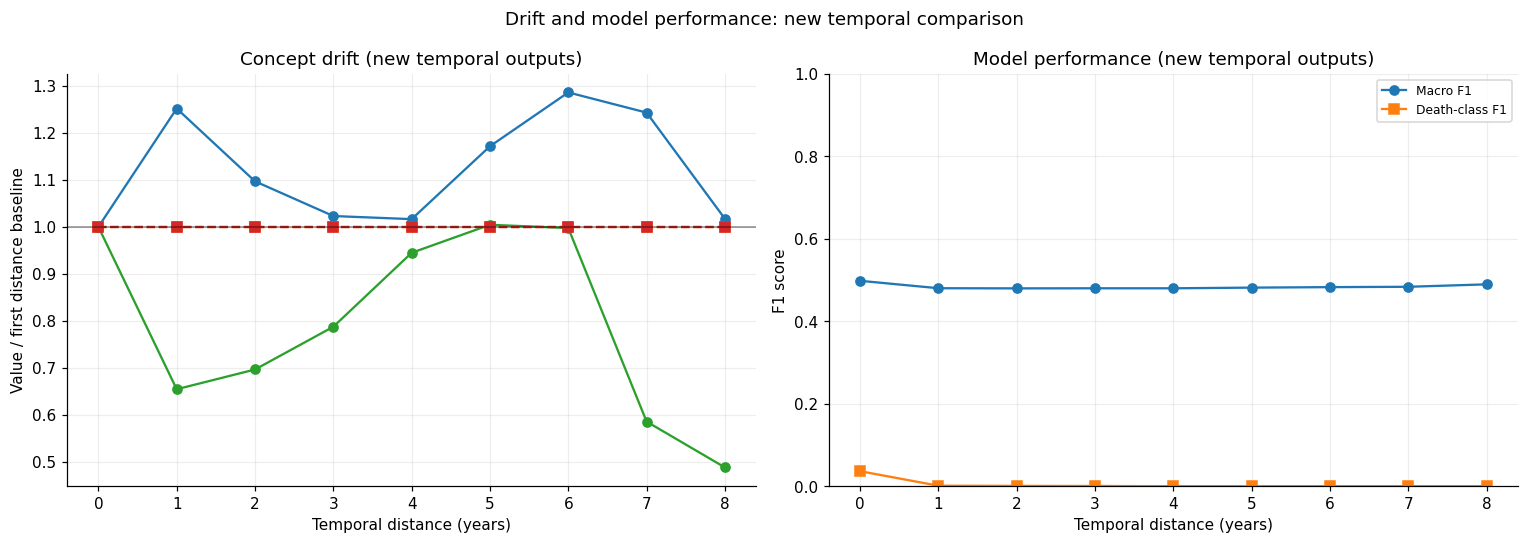

In [8]:
def normalize_from_baseline(values: pd.Series) -> pd.Series:
    values = pd.to_numeric(values, errors="coerce")
    finite = values.dropna()
    baseline = finite.iloc[0] if len(finite) else np.nan
    if np.isfinite(baseline) and baseline != 0:
        return values / baseline
    return pd.Series(np.nan, index=values.index, dtype=float)


def plot_new_temporal_drift() -> None:
    concept = factor_by_distance[
        factor_by_distance["cohort_view"].eq("all_comer")
    ].copy()
    model = performance_by_distance[
        performance_by_distance["cohort_view"].eq("all_comer")
    ].copy()
    fig, (drift_axis, model_axis) = plt.subplots(1, 2, figsize=(14, 5))
    for rule_source, rows in concept.groupby("rule_source"):
        rows = rows.sort_values("temporal_distance")
        drift_axis.plot(
            rows["temporal_distance"],
            normalize_from_baseline(rows["prevalence_ratio"]),
            marker="o",
            label=f"{rule_source}: prevalence ratio",
        )
        drift_axis.plot(
            rows["temporal_distance"],
            normalize_from_baseline(rows["geometric_factor_recurrence"]),
            marker="s",
            linestyle="--",
            label=f"{rule_source}: geometric recurrence",
        )
    drift_axis.axhline(1.0, color="black", linewidth=1, alpha=0.45)
    drift_axis.set(
        title="Concept drift (new temporal outputs)",
        xlabel="Temporal distance (years)",
        ylabel="Value / first distance baseline",
    )
    model = model.sort_values("temporal_distance")
    model_axis.plot(model["temporal_distance"], model["macro_f1"], marker="o", label="Macro F1")
    model_axis.plot(model["temporal_distance"], model["death_f1"], marker="s", label="Death-class F1")
    model_axis.set_ylim(0.0, 1.0)
    model_axis.set(
        title="Model performance (new temporal outputs)",
        xlabel="Temporal distance (years)",
        ylabel="F1 score",
    )
    model_axis.legend(fontsize=8)
    fig.suptitle("Drift and model performance: new temporal comparison")
    finish_figure(fig, "drift_model_new_temporal")


plot_new_temporal_drift()
model_performance_source = str(TEMPORAL_PARENT_PATH)


## Pooled semantic transfer

Only direct run-0 pairs are compared. Subsets overlap, so one pair/threshold may
appear in several subset rows. Robust membership is explicitly post-hoc because
it uses held-out pooled transfer.



,subset,n_rows,n_pairs,n_factors,precision_mean,recall_mean,transfer_f2_mean,transfer_f2_min_mean,transfer_f2_worst,directional_f2_asymmetry,threshold_f2_range,target_cohort_jaccard,selected_cohort_jaccard,cosine_similarity
0,all,3585.0,717.0,156.0,0.003710,0.004162,0.004035,0.002213,0.0,0.003644,0.011210,0.463058,0.995754,0.132837
1,non_dead,3585.0,717.0,156.0,0.003710,0.004162,0.004035,0.002213,0.0,0.003644,0.011210,0.463058,0.995754,0.132837
2,precision_recall,170.0,34.0,6.0,0.078235,0.087764,0.085086,0.046665,0.0,0.076842,0.236405,0.859247,0.910453,0.967294
3,f2,45.0,9.0,1.0,0.295553,0.331554,0.321437,0.176292,0.0,0.290291,0.893085,0.872234,0.661711,0.965038
4,robust,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


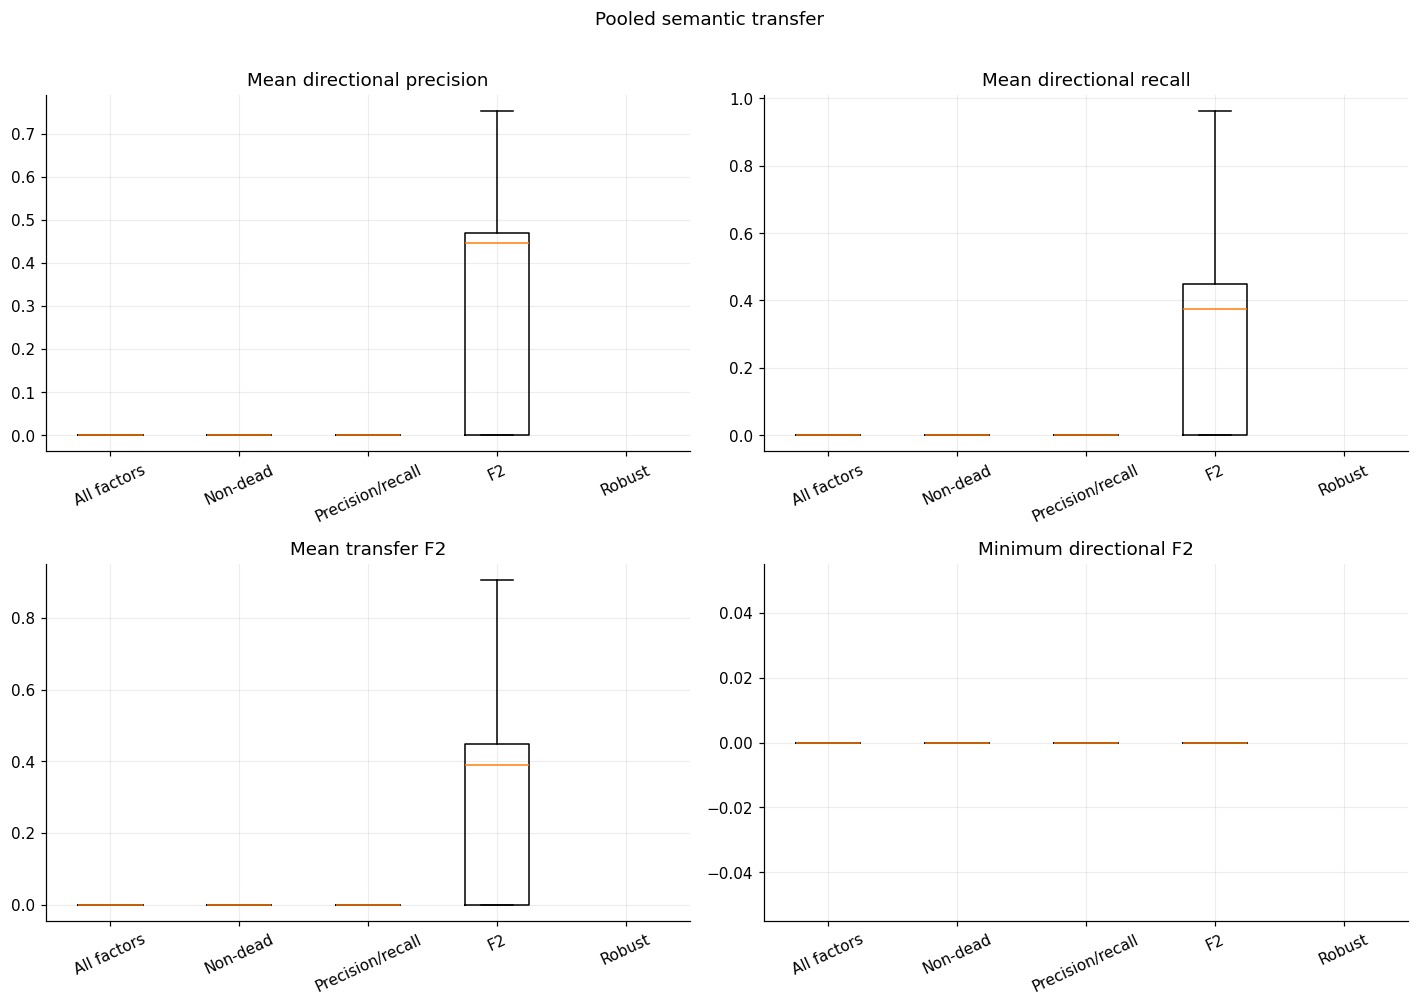

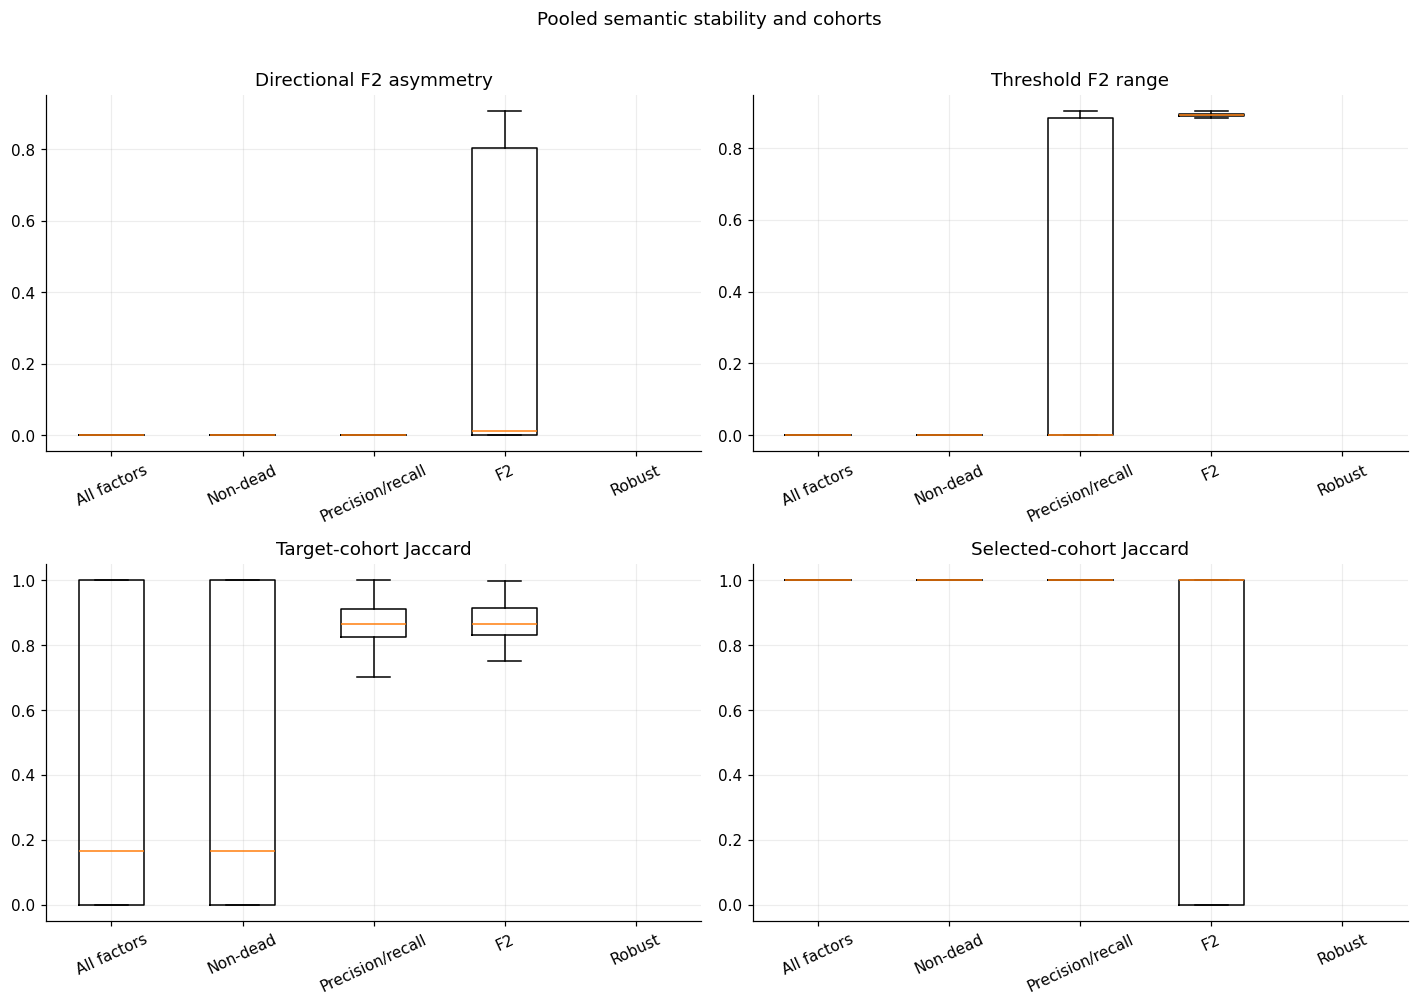

/tmp/ipykernel_806603/973731216.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


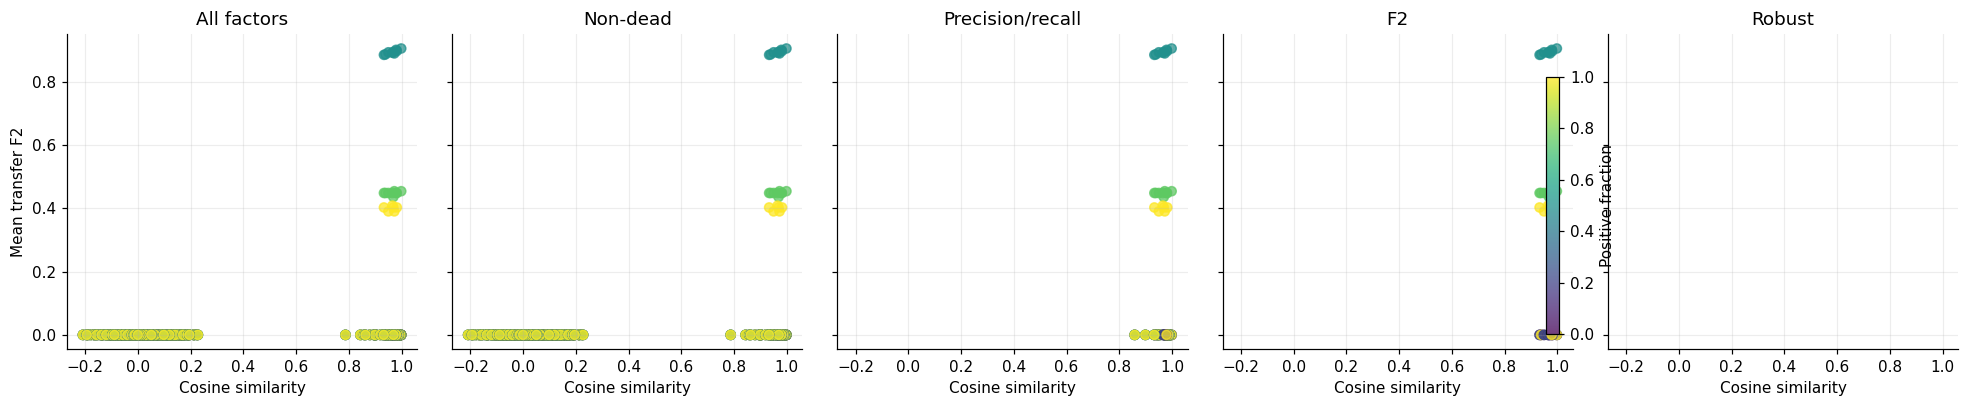

In [9]:
def add_semantic_derived_columns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    for column in (
        "i_to_j_precision", "i_to_j_recall", "i_to_j_f2",
        "j_to_i_precision", "j_to_i_recall", "j_to_i_f2",
        "transfer_mean_f2", "transfer_min_f2", "target_cohort_jaccard",
        "selected_cohort_jaccard", "cos_sim",
    ):
        if column in result:
            result[column] = pd.to_numeric(result[column], errors="coerce")
    result["precision_mean"] = result[["i_to_j_precision", "j_to_i_precision"]].mean(axis=1)
    result["recall_mean"] = result[["i_to_j_recall", "j_to_i_recall"]].mean(axis=1)
    result["directional_f2_asymmetry"] = (
        result["i_to_j_f2"] - result["j_to_i_f2"]
    ).abs()
    stability_keys = ["pair_id", "canonical_factor", "other_run"]
    if "class_value" in result.columns:
        stability_keys.append("class_value")
    stability = (
        result.groupby(stability_keys, dropna=False)["transfer_mean_f2"]
        .agg(threshold_f2_min="min", threshold_f2_max="max")
        .reset_index()
    )
    stability["threshold_f2_range"] = (
        stability["threshold_f2_max"] - stability["threshold_f2_min"]
    )
    return result.merge(
        stability[
            stability_keys + ["threshold_f2_range"]
        ],
        on=stability_keys,
        how="left",
        validate="many_to_one",
    )


def expand_by_subset(
    direct: pd.DataFrame,
    membership: pd.DataFrame,
) -> pd.DataFrame:
    selected_membership = membership[membership["selected"]][
        ["factor_id", "subset"]
    ].rename(columns={"factor_id": "canonical_factor"})
    return direct.merge(
        selected_membership,
        on="canonical_factor",
        how="inner",
        validate="many_to_many",
    )


semantic_metrics = expand_by_subset(
    add_semantic_derived_columns(direct_metrics),
    factor_membership,
)
semantic_metrics["robust_is_posthoc"] = semantic_metrics["subset"] == "robust"
semantic_metrics.to_csv(OUTPUT_DIR / "semantic_metrics.csv", index=False)

semantic_summary = (
    semantic_metrics.groupby("subset")
    .agg(
        n_rows=("pair_id", "size"),
        n_pairs=("pair_id", "nunique"),
        n_factors=("canonical_factor", "nunique"),
        precision_mean=("precision_mean", "mean"),
        recall_mean=("recall_mean", "mean"),
        transfer_f2_mean=("transfer_mean_f2", "mean"),
        transfer_f2_min_mean=("transfer_min_f2", "mean"),
        transfer_f2_worst=("transfer_min_f2", "min"),
        directional_f2_asymmetry=("directional_f2_asymmetry", "mean"),
        threshold_f2_range=("threshold_f2_range", "mean"),
        target_cohort_jaccard=("target_cohort_jaccard", "mean"),
        selected_cohort_jaccard=("selected_cohort_jaccard", "mean"),
        cosine_similarity=("cos_sim", "mean"),
    )
    .reindex(SUBSET_ORDER)
    .reset_index()
)
semantic_summary.to_csv(OUTPUT_DIR / "semantic_summary.csv", index=False)
display(semantic_summary)


def subset_boxplots(
    frame: pd.DataFrame,
    metrics: Sequence[tuple[str, str]],
    filename: str,
    title: str,
) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    for axis, (metric, label) in zip(axes.flat, metrics):
        values = [
            frame.loc[frame["subset"] == subset, metric].dropna().to_numpy()
            for subset in SUBSET_ORDER
        ]
        axis.boxplot(
            values,
            tick_labels=[SUBSET_LABELS[subset] for subset in SUBSET_ORDER],
            showfliers=False,
        )
        axis.set_title(label)
        axis.tick_params(axis="x", rotation=25)
    fig.suptitle(title, y=1.01)
    finish_figure(fig, filename)


subset_boxplots(
    semantic_metrics,
    (
        ("precision_mean", "Mean directional precision"),
        ("recall_mean", "Mean directional recall"),
        ("transfer_mean_f2", "Mean transfer F2"),
        ("transfer_min_f2", "Minimum directional F2"),
    ),
    "semantic_pooled_core",
    "Pooled semantic transfer",
)
subset_boxplots(
    semantic_metrics,
    (
        ("directional_f2_asymmetry", "Directional F2 asymmetry"),
        ("threshold_f2_range", "Threshold F2 range"),
        ("target_cohort_jaccard", "Target-cohort Jaccard"),
        ("selected_cohort_jaccard", "Selected-cohort Jaccard"),
    ),
    "semantic_pooled_stability",
    "Pooled semantic stability and cohorts",
)

fig, axes = plt.subplots(1, len(SUBSET_ORDER), figsize=(18, 3.8), sharex=True, sharey=True)
for axis, subset in zip(axes, SUBSET_ORDER):
    rows = semantic_metrics[semantic_metrics["subset"] == subset]
    scatter = axis.scatter(
        rows["cos_sim"],
        rows["transfer_mean_f2"],
        c=rows["positive_fraction"],
        cmap="viridis",
        alpha=0.75,
    )
    axis.set_title(SUBSET_LABELS[subset])
    axis.set_xlabel("Cosine similarity")
axes[0].set_ylabel("Mean transfer F2")
if len(semantic_metrics):
    fig.colorbar(scatter, ax=axes, label="Positive fraction", shrink=0.8)
finish_figure(fig, "geometry_vs_transfer")



## Outcome-stratified semantic transfer

Rules, cutoffs, and factor subsets remain frozen. Class rows only evaluate the
held-out final split. Invalid or unsupported cohorts remain explicit.



,subset,class_value,n_rows,n_valid,n_invalid,n_samples_min,n_samples_max,n_positive_i_min,n_positive_i_max,n_positive_j_min,n_positive_j_max,precision_mean,recall_mean,transfer_f2_mean,transfer_f2_min_mean,directional_f2_asymmetry,threshold_f2_range,target_cohort_jaccard,selected_cohort_jaccard
0,all,0,3585,863,2722,3349,3349,0,860,0,858,0.003714,0.004175,0.004046,0.002217,0.003658,0.011231,0.467234,0.995759
1,all,1,3585,436,3149,292,292,0,144,0,144,0.003357,0.003207,0.003175,0.001737,0.002876,0.009290,0.824151,0.995351
2,f2,0,45,45,0,3349,3349,155,829,132,834,0.295900,0.332609,0.322346,0.176633,0.291426,0.894745,0.872599,0.662132
3,f2,1,45,45,0,292,292,1,13,1,13,0.267407,0.255509,0.252957,0.138404,0.229107,0.740080,0.877256,0.629630
4,non_dead,0,3585,863,2722,3349,3349,0,860,0,858,0.003714,0.004175,0.004046,0.002217,0.003658,0.011231,0.467234,0.995759
5,non_dead,1,3585,436,3149,292,292,0,144,0,144,0.003357,0.003207,0.003175,0.001737,0.002876,0.009290,0.824151,0.995351
6,precision_recall,0,170,170,0,3349,3349,47,829,39,834,0.078326,0.088044,0.085327,0.046756,0.077142,0.236844,0.861090,0.910564
7,precision_recall,1,170,170,0,292,292,1,144,1,144,0.070784,0.067635,0.066959,0.036636,0.060646,0.195903,0.833811,0.901961


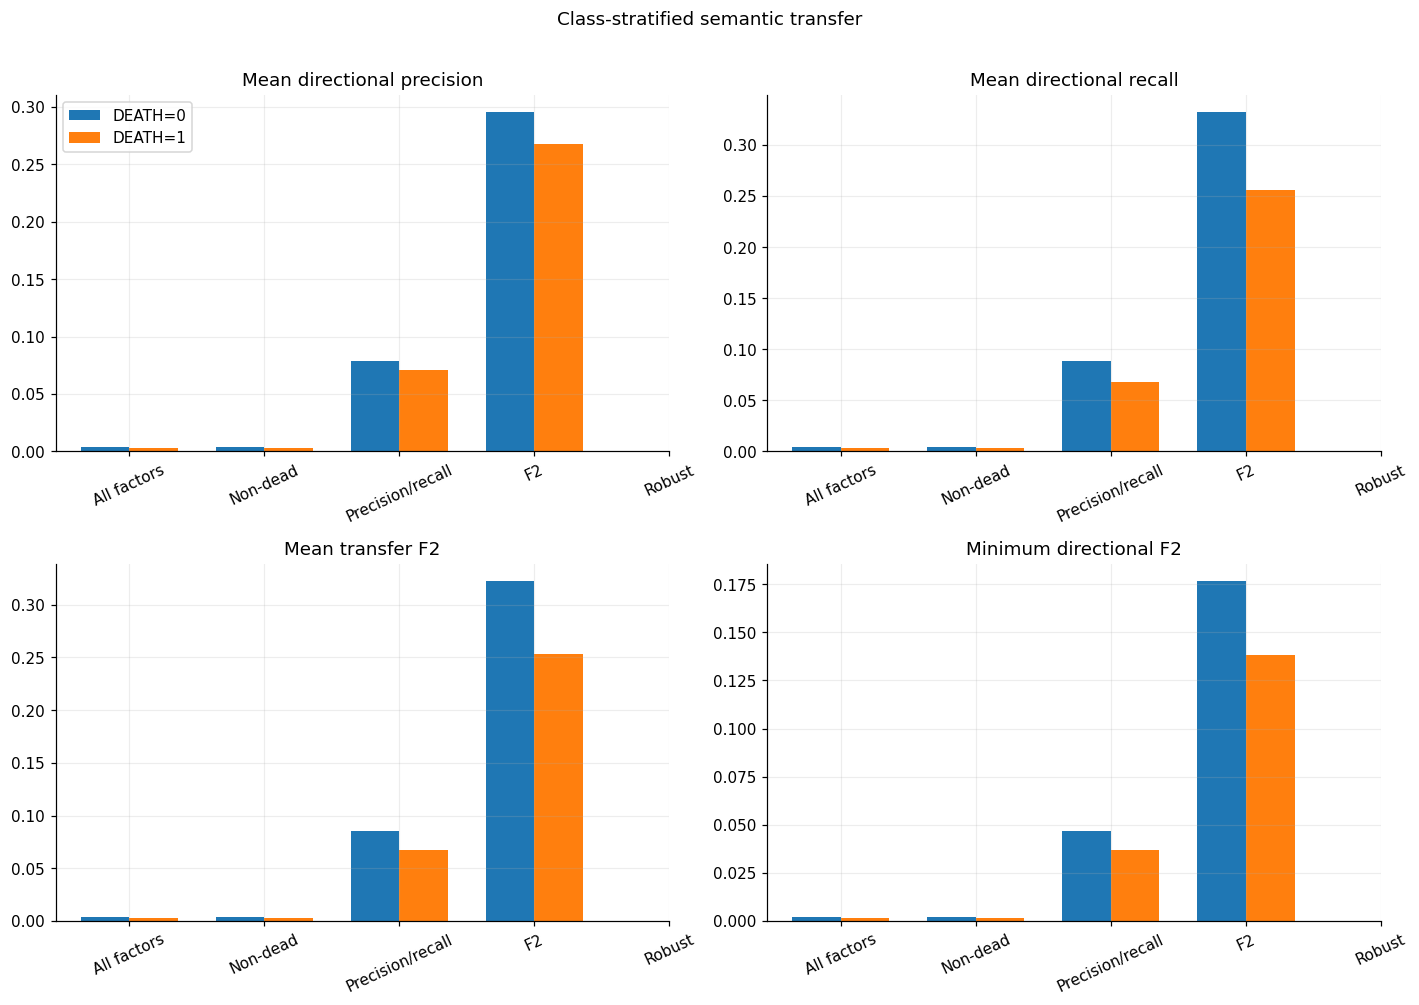

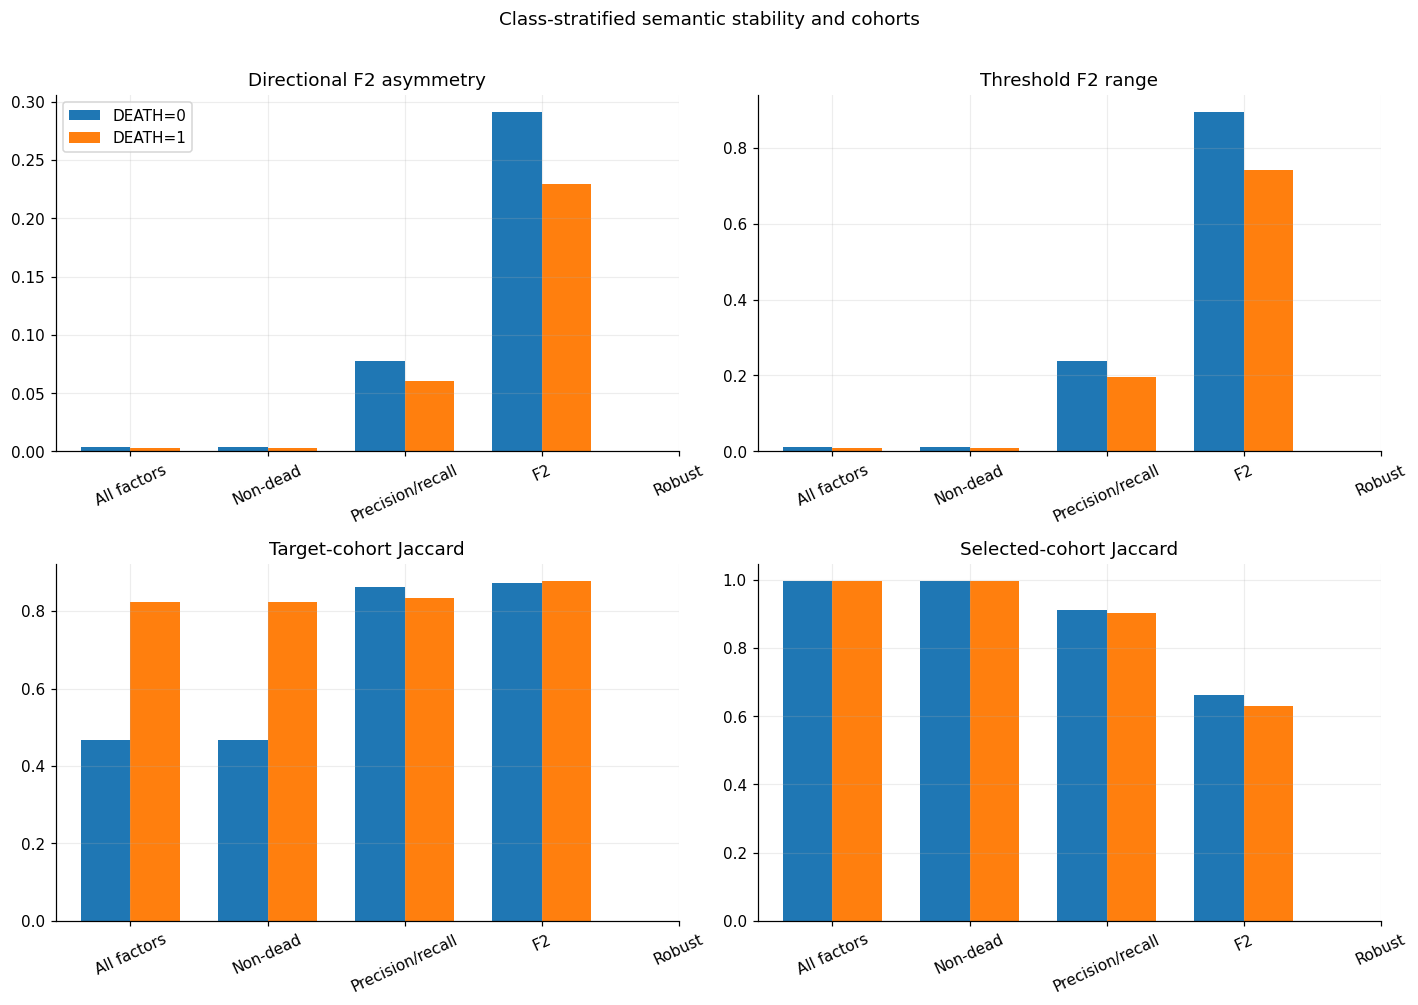

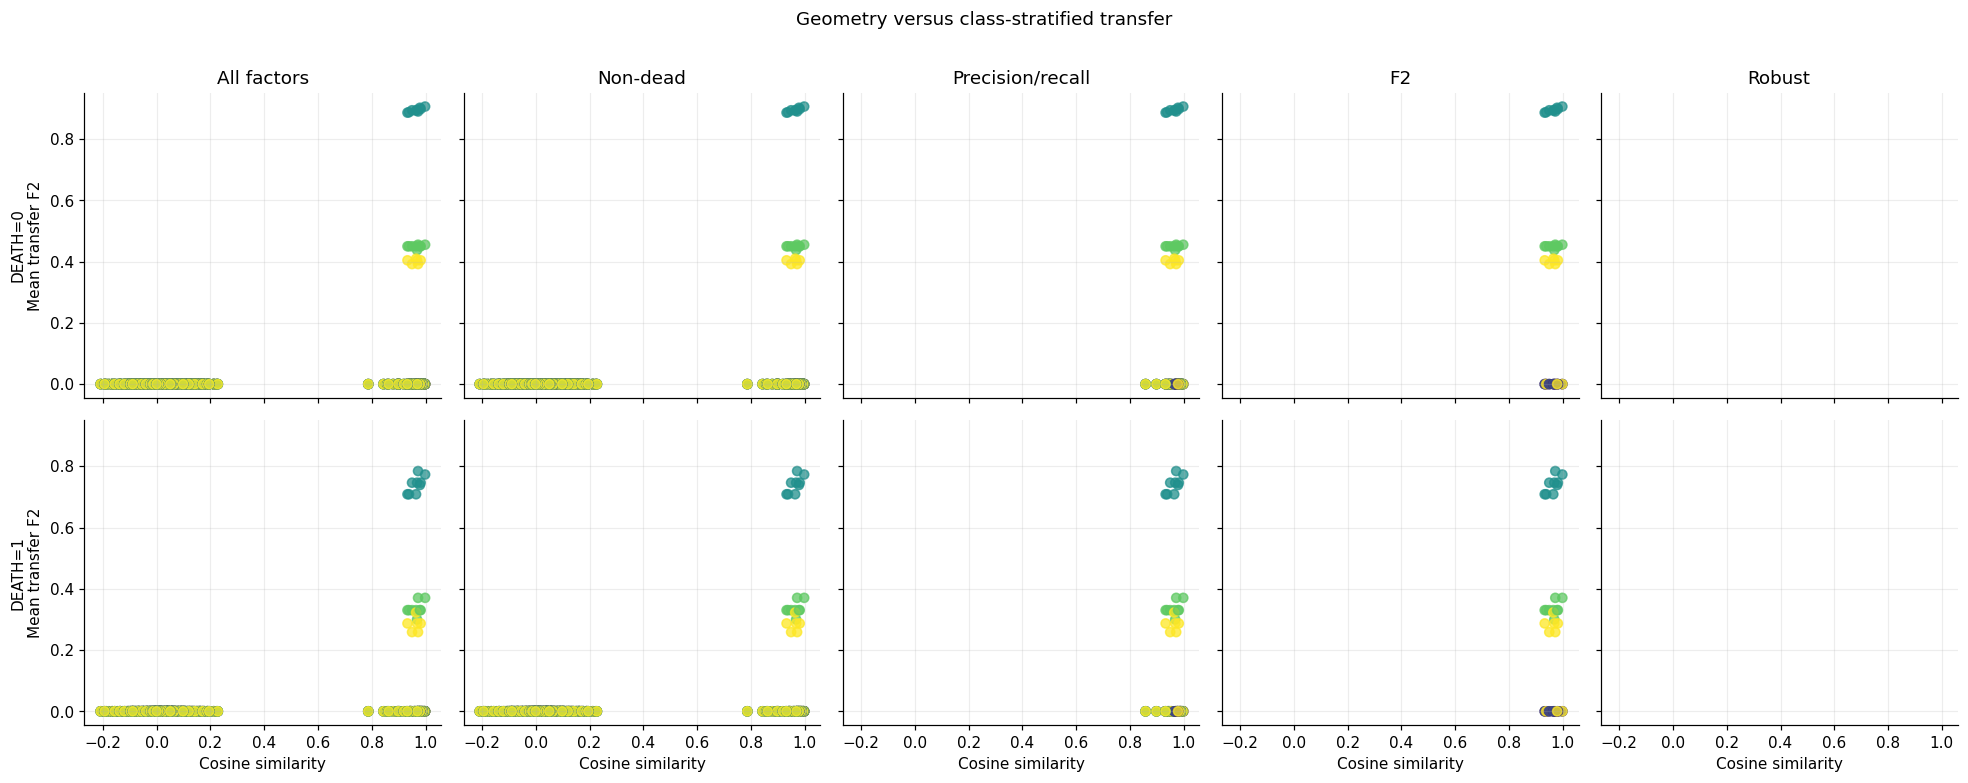

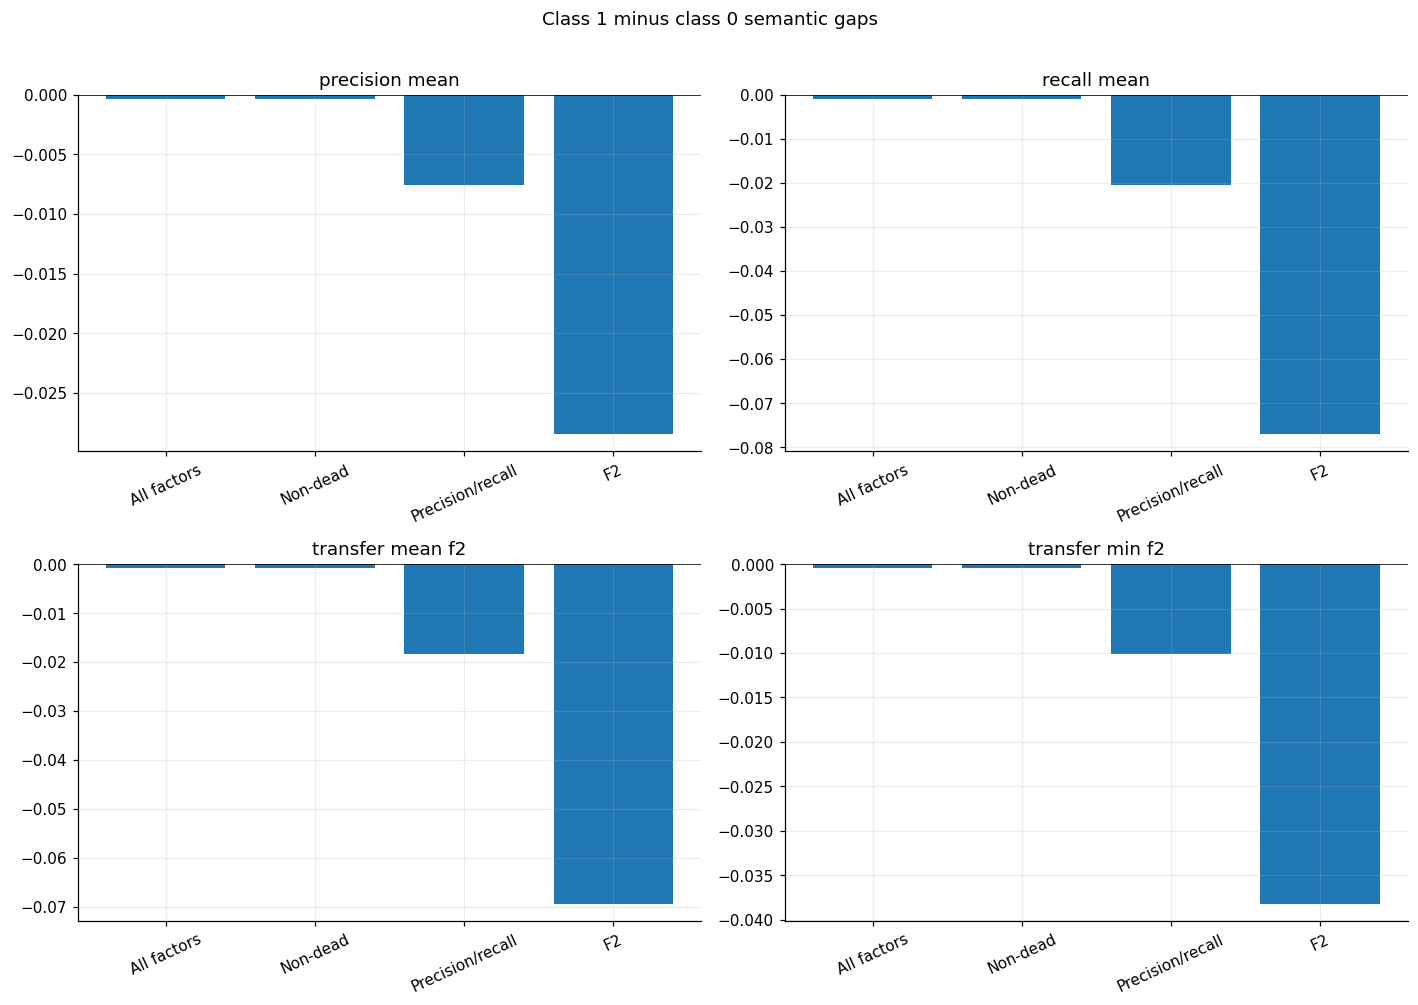

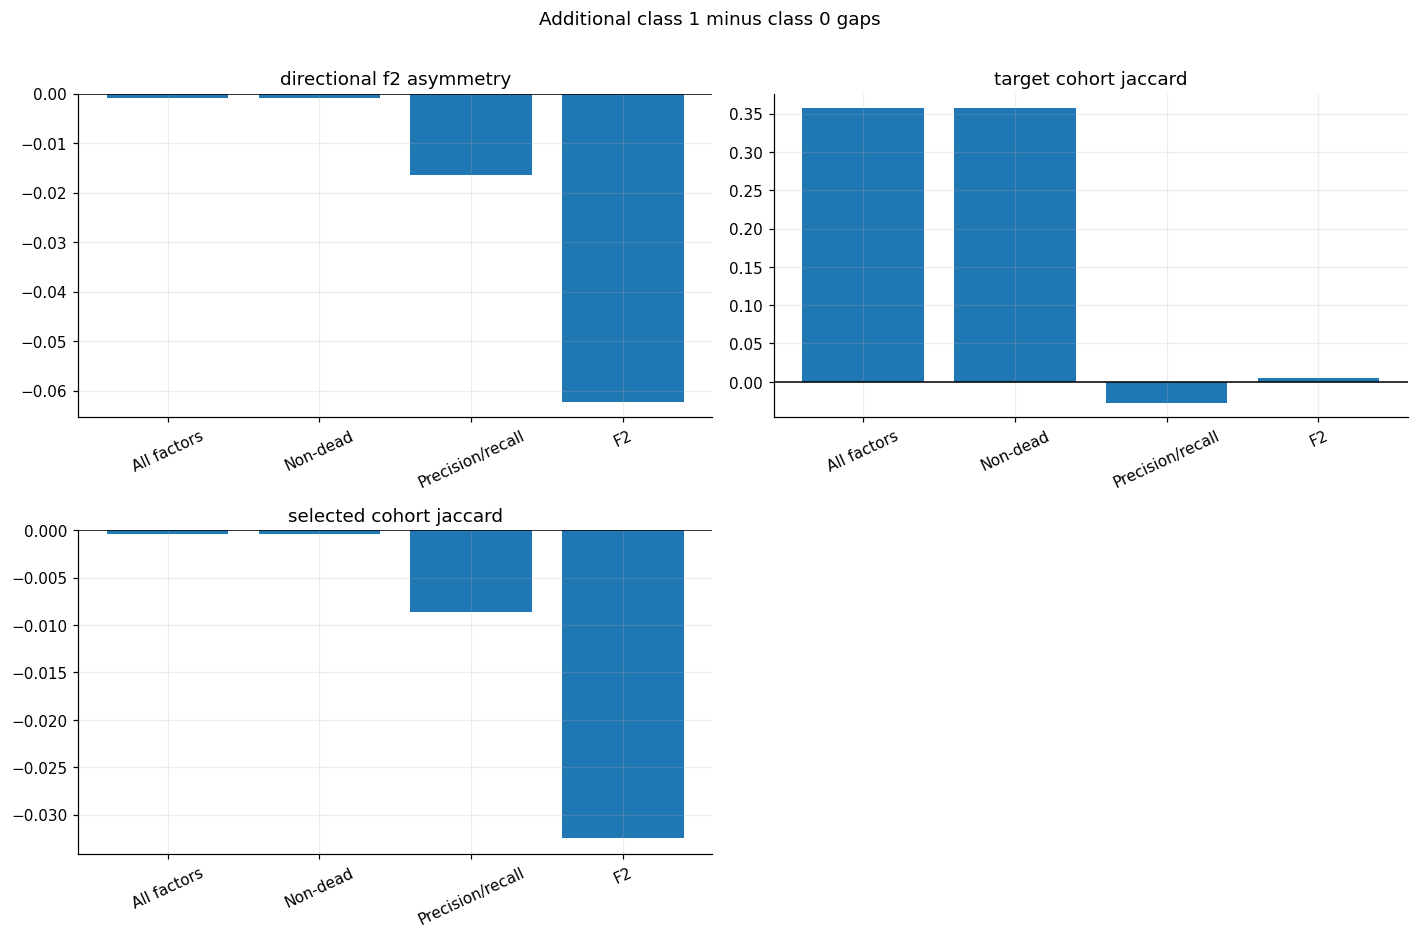

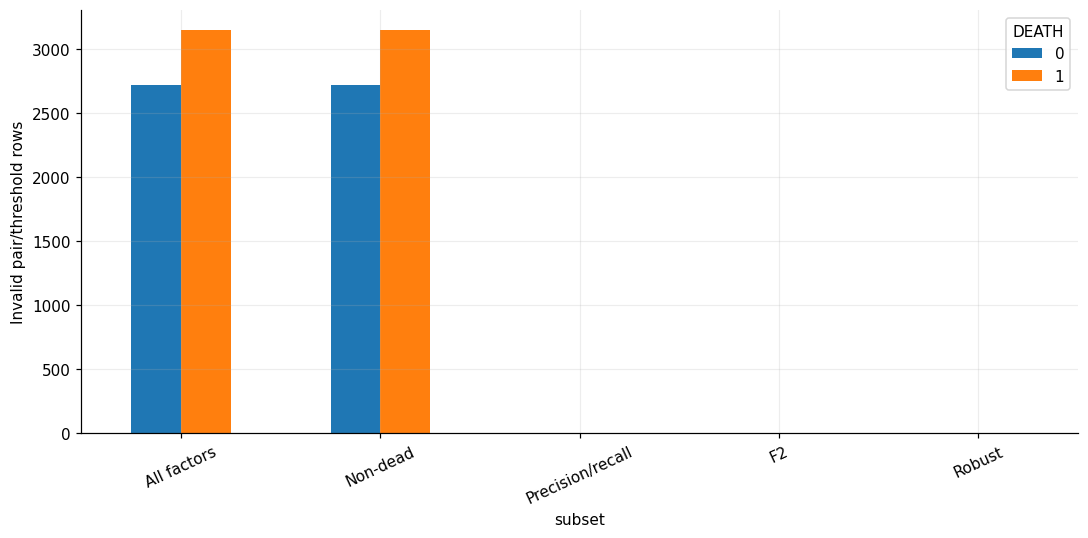

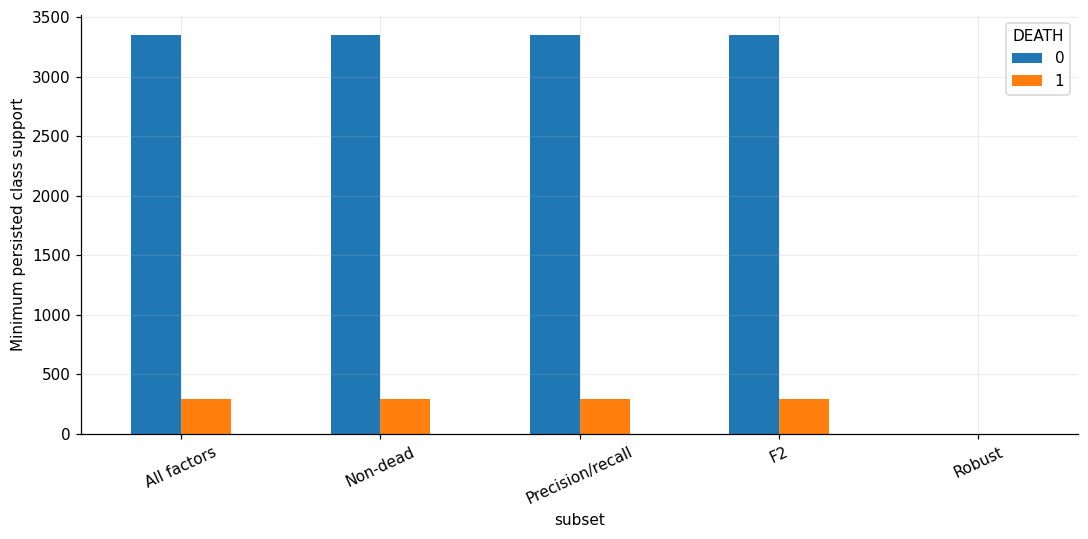

In [10]:
direct_class_metrics = direct_semantic_rows(
    artifacts["pair_metrics_class"], CANONICAL_RUN
)
semantic_metrics_class = expand_by_subset(
    add_semantic_derived_columns(direct_class_metrics),
    factor_membership,
)
semantic_metrics_class["class_value"] = pd.to_numeric(
    semantic_metrics_class["class_value"], errors="coerce"
)
semantic_metrics_class["class_valid"] = (
    semantic_metrics_class["class_valid"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False})
    .fillna(False)
)
semantic_metrics_class["robust_is_posthoc"] = (
    semantic_metrics_class["subset"] == "robust"
)
semantic_metrics_class.to_csv(
    OUTPUT_DIR / "semantic_metrics_by_class.csv", index=False
)

semantic_summary_class = (
    semantic_metrics_class.groupby(["subset", "class_value"], dropna=False)
    .agg(
        n_rows=("pair_id", "size"),
        n_valid=("class_valid", "sum"),
        n_invalid=("class_valid", lambda values: int((~values).sum())),
        n_samples_min=("class_n_samples", "min"),
        n_samples_max=("class_n_samples", "max"),
        n_positive_i_min=("class_n_positive_i", "min"),
        n_positive_i_max=("class_n_positive_i", "max"),
        n_positive_j_min=("class_n_positive_j", "min"),
        n_positive_j_max=("class_n_positive_j", "max"),
        precision_mean=("precision_mean", "mean"),
        recall_mean=("recall_mean", "mean"),
        transfer_f2_mean=("transfer_mean_f2", "mean"),
        transfer_f2_min_mean=("transfer_min_f2", "mean"),
        directional_f2_asymmetry=("directional_f2_asymmetry", "mean"),
        threshold_f2_range=("threshold_f2_range", "mean"),
        target_cohort_jaccard=("target_cohort_jaccard", "mean"),
        selected_cohort_jaccard=("selected_cohort_jaccard", "mean"),
    )
    .reset_index()
)
semantic_summary_class.to_csv(
    OUTPUT_DIR / "semantic_summary_by_class.csv", index=False
)

gap_keys = ["subset", "pair_id", "canonical_factor", "other_run", "threshold_name"]
class_zero = semantic_metrics_class[
    semantic_metrics_class["class_value"] == 0
].copy()
class_one = semantic_metrics_class[
    semantic_metrics_class["class_value"] == 1
].copy()
gap_metrics = (
    class_one.merge(
        class_zero,
        on=gap_keys,
        how="outer",
        suffixes=("_class1", "_class0"),
        indicator=True,
        validate="one_to_one",
    )
)
for metric in (
    "precision_mean",
    "recall_mean",
    "transfer_mean_f2",
    "transfer_min_f2",
    "directional_f2_asymmetry",
    "target_cohort_jaccard",
    "selected_cohort_jaccard",
):
    gap_metrics[f"{metric}_gap_class1_minus_class0"] = (
        gap_metrics[f"{metric}_class1"] - gap_metrics[f"{metric}_class0"]
    )
gap_metrics.to_csv(OUTPUT_DIR / "semantic_class_gaps.csv", index=False)
display(semantic_summary_class)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
class_plot_metrics = (
    ("precision_mean", "Mean directional precision"),
    ("recall_mean", "Mean directional recall"),
    ("transfer_mean_f2", "Mean transfer F2"),
    ("transfer_min_f2", "Minimum directional F2"),
)
positions = np.arange(len(SUBSET_ORDER))
width = 0.36
for axis, (metric, label) in zip(axes.flat, class_plot_metrics):
    for offset, class_value in ((-width / 2, 0), (width / 2, 1)):
        summary = (
            semantic_metrics_class[
                semantic_metrics_class["class_value"] == class_value
            ]
            .groupby("subset")[metric]
            .mean()
            .reindex(SUBSET_ORDER)
        )
        axis.bar(
            positions + offset,
            summary,
            width=width,
            label=f"DEATH={class_value}",
        )
    axis.set_title(label)
    axis.set_xticks(positions, [SUBSET_LABELS[name] for name in SUBSET_ORDER], rotation=25)
axes[0, 0].legend()
fig.suptitle("Class-stratified semantic transfer", y=1.01)
finish_figure(fig, "semantic_by_class")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
class_stability_metrics = (
    ("directional_f2_asymmetry", "Directional F2 asymmetry"),
    ("threshold_f2_range", "Threshold F2 range"),
    ("target_cohort_jaccard", "Target-cohort Jaccard"),
    ("selected_cohort_jaccard", "Selected-cohort Jaccard"),
)
for axis, (metric, label) in zip(axes.flat, class_stability_metrics):
    for offset, class_value in ((-width / 2, 0), (width / 2, 1)):
        summary = (
            semantic_metrics_class[
                semantic_metrics_class["class_value"] == class_value
            ]
            .groupby("subset")[metric]
            .mean()
            .reindex(SUBSET_ORDER)
        )
        axis.bar(
            positions + offset,
            summary,
            width=width,
            label=f"DEATH={class_value}",
        )
    axis.set_title(label)
    axis.set_xticks(
        positions,
        [SUBSET_LABELS[name] for name in SUBSET_ORDER],
        rotation=25,
    )
axes[0, 0].legend()
fig.suptitle("Class-stratified semantic stability and cohorts", y=1.01)
finish_figure(fig, "semantic_by_class_stability")

fig, axes = plt.subplots(
    len(OUTCOME_CLASSES),
    len(SUBSET_ORDER),
    figsize=(18, 7),
    sharex=True,
    sharey=True,
    squeeze=False,
)
for row_index, class_value in enumerate(OUTCOME_CLASSES):
    for column_index, subset in enumerate(SUBSET_ORDER):
        axis = axes[row_index, column_index]
        rows = semantic_metrics_class[
            (semantic_metrics_class["class_value"] == class_value)
            & (semantic_metrics_class["subset"] == subset)
        ]
        axis.scatter(
            rows["cos_sim"],
            rows["transfer_mean_f2"],
            c=rows["positive_fraction"],
            cmap="viridis",
            alpha=0.75,
        )
        if row_index == 0:
            axis.set_title(SUBSET_LABELS[subset])
        if column_index == 0:
            axis.set_ylabel(f"DEATH={class_value}\nMean transfer F2")
        if row_index == len(OUTCOME_CLASSES) - 1:
            axis.set_xlabel("Cosine similarity")
fig.suptitle("Geometry versus class-stratified transfer", y=1.01)
finish_figure(fig, "geometry_vs_transfer_by_class")

gap_columns = [
    column for column in gap_metrics
    if column.endswith("_gap_class1_minus_class0")
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for axis, metric in zip(axes.flat, gap_columns[:4]):
    values = (
        gap_metrics.groupby("subset")[metric]
        .mean()
        .reindex(SUBSET_ORDER)
    )
    axis.bar(
        [SUBSET_LABELS[name] for name in SUBSET_ORDER],
        values,
    )
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(metric.removesuffix("_gap_class1_minus_class0").replace("_", " "))
    axis.tick_params(axis="x", rotation=25)
fig.suptitle("Class 1 minus class 0 semantic gaps", y=1.01)
finish_figure(fig, "semantic_class_gaps")

remaining_gap_columns = gap_columns[4:]
if remaining_gap_columns:
    n_columns = 2
    n_rows = math.ceil(len(remaining_gap_columns) / n_columns)
    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(13, 4.2 * n_rows),
        squeeze=False,
    )
    for axis, metric in zip(axes.flat, remaining_gap_columns):
        values = (
            gap_metrics.groupby("subset")[metric]
            .mean()
            .reindex(SUBSET_ORDER)
        )
        axis.bar(
            [SUBSET_LABELS[name] for name in SUBSET_ORDER],
            values,
        )
        axis.axhline(0, color="black", linewidth=1)
        axis.set_title(
            metric.removesuffix("_gap_class1_minus_class0").replace("_", " ")
        )
        axis.tick_params(axis="x", rotation=25)
    for axis in axes.flat[len(remaining_gap_columns):]:
        axis.set_visible(False)
    fig.suptitle("Additional class 1 minus class 0 gaps", y=1.01)
    finish_figure(fig, "semantic_class_gaps_additional")

invalid_reasons = (
    semantic_metrics_class.assign(
        class_reasons=semantic_metrics_class["class_reasons"].fillna("").replace("", "valid")
    )
    .groupby(["subset", "class_value", "class_reasons"])
    .size()
    .rename("n_rows")
    .reset_index()
)
invalid_reasons.to_csv(OUTPUT_DIR / "semantic_class_support_reasons.csv", index=False)

fig, axis = plt.subplots(figsize=(10, 5))
invalid_counts = (
    semantic_summary_class.pivot(
        index="subset", columns="class_value", values="n_invalid"
    )
    .reindex(SUBSET_ORDER)
    .fillna(0)
)
invalid_counts.plot.bar(ax=axis)
axis.set_xticklabels(
    [SUBSET_LABELS[name] for name in SUBSET_ORDER], rotation=25
)
axis.set_ylabel("Invalid pair/threshold rows")
axis.legend(title="DEATH")
finish_figure(fig, "semantic_class_invalid_counts")

fig, axis = plt.subplots(figsize=(10, 5))
support = (
    semantic_summary_class.pivot(
        index="subset", columns="class_value", values="n_samples_min"
    )
    .reindex(SUBSET_ORDER)
    .fillna(0)
)
support.plot.bar(ax=axis)
axis.set_xticklabels(
    [SUBSET_LABELS[name] for name in SUBSET_ORDER], rotation=25
)
axis.set_ylabel("Minimum persisted class support")
axis.legend(title="DEATH")
finish_figure(fig, "semantic_class_support")



## Compact analysis manifest



In [11]:
temporal_status_counts = (
    factor_year_metrics["status"].fillna("missing").value_counts().to_dict()
    if "status" in factor_year_metrics
    else {}
)
analysis_manifest = {
    "legacy_source_commit": "faf6cfa",
    "runner_hash": RUNNER_HASH_RESOLVED,
    "canonical_run": CANONICAL_RUN,
    "activation_epsilon": ACTIVATION_EPSILON,
    "robust_f2_minimum": ROBUST_F2_MINIMUM,
    "robust_subset_is_posthoc": True,
    "source_runner_dir": str(artifacts["runner_dir"]),
    "source_semantic_dir": str(artifacts["semantic_dir"]),
    "temporal_parent_manifest": str(TEMPORAL_PARENT_PATH),
    "temporal_runner_hash": TEMPORAL_PARENT.get("runner_hash"),
    "temporal_schema_version": TEMPORAL_PARENT.get("schema_version"),
    "output_dir": str(OUTPUT_DIR),
    "model_performance_source": model_performance_source,
    "n_rows": len(artifacts["X"]),
    "n_factors": n_factors,
    "run_ids": list(artifacts["run_ids"]),
    "threshold_names": list(artifacts["threshold_names"]),
    "subset_counts": {
        row["subset"]: int(row["n_selected"])
        for row in inventory_rows
    },
    "temporal_status_counts": {
        str(key): int(value) for key, value in temporal_status_counts.items()
    },
    "source_artifacts_modified": False,
}
with (OUTPUT_DIR / "analysis_manifest_legacy.json").open("w", encoding="utf-8") as handle:
    json.dump(analysis_manifest, handle, indent=2, sort_keys=True, allow_nan=False)

print("Legacy comprehensive analysis complete.")
print(f"Tables and plots: {OUTPUT_DIR}")
display(pd.DataFrame([analysis_manifest]).T.rename(columns={0: "value"}))


Legacy comprehensive analysis complete.
Tables and plots: stats/analysis/robustness/a89788e527b7c1ed3003


,value
legacy_source_commit,faf6cfa
runner_hash,a89788e527b7c1ed3003
canonical_run,0
activation_epsilon,0.00001
robust_f2_minimum,0.7
robust_subset_is_posthoc,True
source_runner_dir,stats/comparison/a89788e527b7c1ed3003
source_semantic_dir,/home/joaomarcostomaz/SAE-TCAV-extension/SAE-T...
temporal_parent_manifest,stats/temporal_robustness/6284a624c93d5b632390...
temporal_runner_hash,6284a624c93d5b632390
